# Build the carbon ledger
- track C stock flows
- constrain availability for use


In [533]:
# add path to sispeuede to sys.path in python
import sys
import pathlib
path_git = pathlib.Path("/Users/usuario/git")
for subdir in ["sisepuede", "sisepuede_data_pipeline"]:
    path_cur = path_git.joinpath(subdir)
    if str(path_cur) not in sys.path:
        sys.path.append(str(path_cur))


path_pipeline = path_git.joinpath("sisepuede_data_pipeline")

import warnings
warnings.filterwarnings("ignore")


import os, os.path
import numpy as np
import pandas as pd
import rioxarray as rx

#from sisepuede.core.model_attributes import *
import sisepuede.core.model_attributes as ma
import sisepuede.models.afolu as mafl
import sisepuede.models.ippu as mi
import sisepuede.models.circular_economy as mc
import sisepuede.models.energy_production as ml
import sisepuede.models.energy_consumption as me
import sisepuede.models.socioeconomic as se
import sisepuede.pipeline.projection_utilities as sppu
import sisepuede.core.model_variable as mv

#import sisepuede.legacy.setup_analysis as sa
#import sisepuede.legacy.data_api as api
import sisepuede.manager.sisepuede_models as sm
import sisepuede.core.support_classes as sc
import sisepuede.utilities._sql as squ
import sisepuede.utilities._toolbox as sf
import importlib
import pathlib
import time
import warnings
import matplotlib.pyplot as plt
from typing import *
import inspect
import sisepuede.data_management.ingestion as ing
import logging
import sisepuede.geo.geo_functions as gf
import sisepuede.manager.sisepuede_examples as sxl
import sisepuede.manager.sisepuede_file_structure as sfs
import sisepuede.models.afolu as mafl
import sisepuede.transformers.lib._baselib_afolu as tba
import sisepuede.transformers.lib._baselib_circular_economy as tbc
import sisepuede.transformers.lib._baselib_energy as tbe
import sisepuede.transformers.lib._baselib_general as tbg
import sisepuede.transformers.lib._baselib_ippu as tbi
import sisepuede.utilities._plotting as spu

import afolu.geo.lib._get_gridded_dataset as gridded
import lib.data_construction_utilities as util
import lib.data_objects as do
import lib._geo as geolib
import lib._geo_classes as gcl
import lib.process_utilities as pu
import lib.sisepuede_data_constructs as dc
import lib._util as lutil



import sisepuede.models._arrays as collarrays
np.set_printoptions(linewidth = 150, )




In [534]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [535]:
[x]

['nemomod_entc_biomass_msp_replacement_tag_pp_wind']

In [536]:
# import the file structure, init SISEPUEDEFileStructure(), and get shortcut to model_attributes
import sisepuede.manager.sisepuede_file_structure as sfs
import sisepuede.manager.sisepuede_examples as sxl
importlib.reload(sfs.ma)
importlib.reload(sfs)
importlib.reload(mafl.mec)
importlib.reload(mafl)

file_struct = sfs.SISEPUEDEFileStructure()
matt = file_struct.model_attributes
examples = sxl.SISEPUEDEExamples()

# two versions here; inputs will be overwritten
df_inputs = examples("input_data_frame").copy()
df_examples = examples("input_data_frame").copy()

regions = sc.Regions(matt, )
time_periods = sc.TimePeriods(matt, )
model_afolu = mafl.AFOLU(
    matt, 
    npp_curve = "sem", 
    npp_include_primary_forest = True,
)


##  SOME MODEL VARIABLES
_MODVAR_LNDU_IBAG = matt.get_variable("Initial Above Ground Biomass Stock Factor")
_MODVAR_LNDU_RBGAG = matt.get_variable("Below Ground to Above Ground Biomass Stock Ratio")




"""
sf._write_csv(
    df_examples,
    "/Users/usuario/git/sisepuede/sisepuede/ref/examples/input_data_frame.csv"
)
""";


In [537]:
sf._write_csv(
    df_examples,
    "/Users/usuario/git/sisepuede/sisepuede/ref/examples/input_data_frame.csv"
)

True

In [538]:
import sisepuede.manager.sisepuede_file_structure as sfs
import sisepuede.manager.sisepuede_examples as sxl

file_struct = sfs.SISEPUEDEFileStructure()
matt = file_struct.model_attributes
examples = sxl.SISEPUEDEExamples()

# 
df_examples = examples("input_data_frame").copy()
regions = sc.Regions(matt, )
time_periods = sc.TimePeriods(matt, )


In [539]:
raw_data2 = raw_data.copy()

fields = [
    "deminit_trde_private_and_public_per_capita_passenger_km",
    "deminit_trde_regional_per_capita_passenger_km"
]

raw_data2[fields] *= 6

df_out = models(raw_data2, include_electricitry_in_energy = False, )

df_out["emission_co2e_subsector_total_trns"]


NameError: name 'raw_data' is not defined

In [ ]:
path_fao = "/Users/usuario/SISEPUEDE_DATA_REPOSITORY/FAOSTAT2024/Inputs_FertilizersProduct_E_All_Data_(Normalized)/Inputs_FertilizersProduct_E_All_Data_(Normalized).csv"
dataset = do.DatasetFAO(path_fao, )

path_fao_2 = "/Users/usuario/SISEPUEDE_DATA_REPOSITORY/FAOSTAT2024/Inputs_FertilizersNutrient_E_All_Data_(Normalized)/Inputs_FertilizersNutrient_E_All_Data_(Normalized).csv"
dataset_n = do.DatasetFAO(path_fao_2, )


In [ ]:
kk = dataset_n.get_subset(
    area = "Egypt",
    item = "Nutrient nitrogen N (total)",
    #element = [
    #    #"Export Quantity",
    #    "Import Quantity",
    #    #"Production",
    #],
    year = 2019
)[dataset.field_item].unique()

kk = dataset.get_subset(
    area = "Egypt",
    #element = "Production",
    element = [
        "Export Quantity",
        "Import Quantity",
        "Production",
    ],
    #item = "Ammonia, anhydrous",
    year = 2019
)#[dataset.field_item].unique()

kk



In [ ]:
[x for x in matt.all_variable_fields_input if x not in df_input]

In [ ]:
"""
import afolu.area_bounds.modvars_area_bounds as mab
importlib.reload(mab)
path_config_mab = path_pipeline.joinpath("afolu", "area_bounds", "config.yaml")
reader_mab = pu.InputsReader(
    path_config_mab,
    repository = repo,
    sisepuede_constructs = construct,
)

dict_mab = mab.main(
    inputs_reader = reader_mab,
    return_behavior = "data_and_write",
    sisepuede_constructs = construct,
)
""";

In [ ]:
import lib.process_utilities as pu
import lib.sisepuede_data_constructs as dc
import lib._util as lutil


importlib.reload(dc.sc)
importlib.reload(sc)

construct = dc.SISEPUEDEDataConstructs(
    path_output_database = "/Users/usuario/git/sisepuede_data_pipeline/sisepuede_inputs.sqlite",
)

path_repo = pathlib.Path("/Users/usuario/SISEPUEDE_DATA_REPOSITORY")
repo = pu.Repository(
    {
        "local": {
            "path": str(path_repo)
        }
    }
)

# get from pipeline and add some defaults
df_from_pipeline = construct.build_inputs_from_database(
    regions_keep = "peru",
    join = "outer"
)
df_from_pipeline = _MODVAR_LNDU_RBGAG.spawn_default_dataframe(
    df_from_pipeline,
    fill_value = 0.25,
)

# read in complete DF
df_base = pd.read_csv("/Users/usuario/git/sisepuede_region_nbs/generic_regions/data/output/sisepuede_raw_inputs_latest_PER.csv", )
df_input = sf.match_df_to_target_df(
    df_base,
    df_from_pipeline,
    [regions.field_iso, time_periods.field_year],
    overwrite_only = False, 
)

df_input = (
    df_input[
        df_input[time_periods.field_year].isin(
            range(2015, 2051)
        )
    ]
    .reset_index(drop = True, )
)

flds_add = [x for x in df_examples.columns if (x not in df_input.columns) and (x in matt.all_variable_fields_input)]
for x in flds_add:
    df_input[x] = df_examples[x].copy()

# drop unnecessary
fields_keep = [
    time_periods.field_time_period,
    time_periods.field_year,
    regions.field_iso
]
fields_drop = [
    x for x in df_input.columns 
    if x not in matt.all_variable_fields_input
    and x not in fields_keep
]

df_input = df_input.drop(columns = fields_drop, )



In [ ]:
sf._write_csv(
    df_base,
    "/Users/usuario/git/sisepuede_region_nbs/generic_regions/data/output/sisepuede_raw_inputs_latest_PER.csv"
)

In [ ]:
sf._write_csv(
    df_examples,
    "/Users/usuario/git/sisepuede/sisepuede/ref/examples/input_data_frame.csv"
)

In [ ]:
"""
CHARCOAL VALS

dict_vals = {
    "nemomod_entc_emissions_activity_ratio_fuel_production_fp_charcoal_tonne_ch4_per_tj": 1.27652835,
    "nemomod_entc_emissions_activity_ratio_fuel_production_fp_charcoal_tonne_n2o_per_tj": 0.002534051,
    "nemomod_entc_input_activity_ratio_fuel_production_fp_charcoal_biomass": 10, # https://energypedia.info/wiki/Charcoal_Production#:~:text=The%20bulk%20density%20of%20charcoal,%2D%20220%20kg%2Fm3.
    "nemomod_entc_output_activity_ratio_fuel_production_fp_charcoal_charcoal": 1,
}


flds_repl = [
    "efficfactor_scoe_heat_energy_commercial_municipal_",
    "efficfactor_scoe_heat_energy_other_se_",
    "efficfactor_scoe_heat_energy_residential_"
]

for fld in flds_repl:
    fld_src = f"{fld}solid_biomass"
    fld_new = f"{fld}charcoal"

    if fld_src not in df_input.columns:
        print(f"dead {fld_src}")
        continue

    df_input[fld_new] = df_input[fld_src].to_numpy()


flds_zero = [
    "exports_enfu_pj_fuel_charcoal",
    "frac_enfu_fuel_demand_imported_pj_fuel_charcoal",
    "frac_inen_energy_metals_charcoal",
    "frac_scoe_heat_energy_commercial_municipal_charcoal",
    "frac_scoe_heat_energy_other_se_charcoal",
    "frac_scoe_heat_energy_residential_charcoal"
]

for fld in flds_zero:
    df_input[fld] = 0 




##  AMMONIA VALS FOR EXAMPLES

dict_ammonia = {
    "demscalar_ippu_ammonia": 1,
    "elasticity_ippu_ammonia_production_to_gdp": 0.5,
    "exports_soil_synthetic_fertilizer_n_tonne": 0,
    "frac_enfu_fuel_n_fuel_ammonia": 0.82,
    "frac_soil_synthetic_fertilizer_n_demand_imported": 0.1,
    "prodinit_ippu_no_fertilizer_feedstock_ammonia_tonne": 0,
}

for k, v in dict_ammonia.items():
    df_examples[k] = v

sf._write_csv(
    df_examples,
    "/Users/usuario/git/sisepuede/sisepuede/ref/examples/input_data_frame.csv"
)
"""
[x for x in df_input.columns if x not in matt.all_variable_fields_input]#df_examples.columns]
[x for x in matt.all_variable_fields_input if x not in df_input.columns]


dict_new_vals = {
    "yf_lndu_average_pastures_tonne_per_ha": 25.0,
    "biomass_frst_ledger_frac_adjustment_threshold": 0.9,
    "biomass_frst_ledger_frac_dead_storage": 0.1,
    "frac_frst_c_in_dry_matter": 0.47,
    "frac_frst_c_in_wood_products": 0.5,
    "frac_frst_c_stock_converted_available_for_use_primary": 0.7,
    "frac_frst_c_stock_converted_available_for_use_secondary": 0.7,
}

fields_drop = [x for x in df_examples.columns if x not in matt.all_variable_fields_input + ["region", "time_period"]]

for k, v in dict_new_vals.items():
    df_examples[k] = v

df_examples = df_examples.drop(
    columns = fields_drop,
)



In [ ]:
import sisepuede.models.energy_production as mep
importlib.reload(mep)
model_enerprod = mep.EnergyProduction(
    matt, 
    dir_jl = file_struct.dir_jl,
    nemomod_reference_files = file_struct.dir_ref_nemo,
    initialize_julia = False,
)


In [ ]:
import sisepuede.models.energy_consumption as mec
importlib.reload(mec)
model_enercons = mec.EnergyConsumption(matt, )

# Code to add subsector variable codes to CSVs

In [ ]:

subsec = matt.subsec_name_enst
subsec_abv = matt.get_subsector_attribute(subsec, "abv_subsector")

field_svc = "Subsector Variable Code"
field_var = "Variable"
field_vartype = "Variable Type"

attr_vardefs = matt.get_attribute_table(
    subsec, 
    table_type = "variable_definitions",
)

model = model_enerprod#model_enercons#model_afolu.model_enercons

# get the table (not cleaned) and 
tab = pd.read_csv(attr_vardefs.fp_table, )
vec_vars = np.array([x.replace("`", "") for x in tab[field_var].to_numpy()])

# get all properties associated with the model variables
prefix_modvars_subsec = f"modvar_{subsec_abv}_"
props_modvars = [x for x in dir(model) if x.startswith(prefix_modvars_subsec)]

# initialize vector of codes out
vec_subsec_code = ["" for x in vec_vars]

for i, m in enumerate(props_modvars):
    modvar_name = getattr(model, m)
    modvar_name = matt.get_variable(modvar_name, )
    if modvar_name is None: continue

    modvar_name = modvar_name.name

    # get index of associated var
    w = np.where(vec_vars == modvar_name)[0]
    if len(w) == 0:
        continue

    if len(w) > 1:
        print("uh oh")

    code = m.replace(prefix_modvars_subsec, "")
    vec_subsec_code[w[0]] = code


if len(vec_subsec_code) != len(set(vec_subsec_code)):
    raise ValueError(f"Multiple code specifications found in subsec {subsec}")
    
tab[field_svc] = vec_subsec_code

fields_pre = [field_vartype, field_var]
fields_ord = [x for x in tab.columns if x not in fields_pre + [field_svc]]
fields_out = fields_pre + [field_svc] + fields_ord

tab = tab.get(fields_out, )


for k in tab[field_svc].to_numpy():
    print(k)

In [ ]:
for k in vec_subsec_code:
    print(k)

In [ ]:
model_afolu.ind_lndu_crop#model_socioeconomic.modvar_gnrl_scalar_pop_density




In [ ]:
cur = matt.get_attribute_table("Energy Fuels", table_type = "variable_definitions").table["subsector_variable_code"].to_numpy()

for i, string in enumerate(cur):
    comparison = vec_subsec_code[i]
    if comparison != string:
        raise RuntimeError(f"Error at {i}")

In [ ]:
vec_subsec_code

In [ ]:
[x for x in matt.all_variable_fields_input if x not in df_examples.columns]

In [ ]:
sf._write_csv(
    df_examples,
    os.path.join(file_struct.dir_ref_examples, "input_data_frame.csv")
)

In [ ]:
df_input_lurf1[[x for x in df_input_lurf1 if ("frac_lvst_max_diet_from_crop_residuals_" in x)]]



In [ ]:
#df_input[[x for x in df_input.columns if ("pij_lndu" in x) and ("to_cropland" in x)]]\
model_afolu.arrays_agrc.arr_agrc_frac_animal_feed.sum(axis = 1)



In [ ]:
importlib.reload(ma)
importlib.reload(mafl.mec)
importlib.reload(mafl.suo)
importlib.reload(mafl.npp)
importlib.reload(mafl.coll_arrays)
importlib.reload(mafl)

model_afolu = mafl.AFOLU(
    matt, 
    npp_curve = "sem", 
    npp_include_primary_forest = True,
)

model_afolu._initialize_array_classes(df_input, )


In [ ]:
if True:
    # try increasing biomass use significantly
    df_overwrite = model_afolu.get_ilu_fuel_shifts_from_biomass(
        df_input_lurf1,
        10*np.ones(df_input_lurf1.shape[0]),
    )
    df_input_lurf1[df_overwrite.columns] = df_overwrite 

In [ ]:
[x for x in df_input_lurf1.columns if "adjust" in x]

In [ ]:
df_input_lurf1["biomass_frst_ledger_frac_adjustment_threshold"]

In [ ]:
[x for x in df_input.columns if "energy" in x and "agrc" in x and "cereals" in x]


In [ ]:
df_input_lurf1["frac_enfu_fuel_demand_imported_pj_fuel_biomass"]
df_input_lurf1["exports_enfu_pj_fuel_charcoal"]


In [ ]:
[x for x in df_input.columns if "export" in x and "elec" in x]


In [ ]:
importlib.reload(ma)
importlib.reload(mafl.bcl)
importlib.reload(mafl.mec)
importlib.reload(mafl.suc)
importlib.reload(mafl.suo)
importlib.reload(mafl.npp)
importlib.reload(mafl.mip)
importlib.reload(mafl.coll_arrays)
importlib.reload(mafl)

model_afolu = mafl.AFOLU(
    matt, 
    #force_lurf_for_settlements = True,
    npp_curve = "sem", 
    npp_include_primary_forest = True,
)

#model_afolu._initialize_array_classes(df_input, )

# TEST ERROR THROWING:
# df_input2 = df_input.copy().get([x for x in df_input.columns if not x.startswith("elasticity_lvst")])
# model_afolu._initialize_array_classes(df_input, )
#df_try = model_afolu(df_input, )
#df0 = pd.DataFrame(model_afolu.arr_land_use, columns = model_afolu.attr_lndu.key_values)

df_input_lurf1 = df_input.copy()

fields = [x for x in df_input_lurf1.columns if ("elast" in x) and ("lvst" in x)]
arr_elast = df_input_lurf1[fields].to_numpy().copy()*2
df_input_lurf1[fields] = arr_elast

fields = [x for x in df_input_lurf1.columns if ("pop_" in x) and ("lvst" in x)]
arr_pop = df_input_lurf1[fields].to_numpy().copy()*1.4
df_input_lurf1[fields] = arr_pop

# some test updates
df_input_lurf1["lndu_reallocation_factor"] = np.sign(sf.ramp_vector(
    df_input_lurf1.shape[0],
    r_0 = 1,
    #r_1 = 25,
))*1.0
#df_input_lurf1["lndu_reallocation_factor"] = 0

df_input_lurf1["scalar_lvst_carrying_capacity"] = 1 + sf.ramp_vector(
    df_input_lurf1.shape[0],
    r_0 = 11,
    #r_1 = 25,
)*-0.4;

# test improving density
df_input_lurf1["scalar_gnrl_population_density_urban"] = 1 + sf.ramp_vector(
    df_input_lurf1.shape[0],
    r_0 = 11,
    #r_1 = 25,
)*0.4;


df_input_lurf1["frac_lvst_max_diet_from_crops_cereal_cattle_dairy"] = 0.05
df_input_lurf1["frac_lvst_max_diet_from_crops_cereal_cattle_nondairy"] = 0.05
df_input_lurf1["frac_lvst_max_diet_from_crops_noncereal_cattle_dairy"] = 0.05
df_input_lurf1["frac_lvst_max_diet_from_crops_noncereal_cattle_nondairy"] = 0.05
df_input_lurf1["frac_lvst_max_diet_from_crop_residuals_cattle_dairy"] = 0.2
df_input_lurf1["frac_lvst_max_diet_from_crop_residuals_cattle_nondairy"] = 0.2
df_input_lurf1["frac_lvst_min_diet_from_pastures_cattle_dairy"] = 0.6
df_input_lurf1["frac_lvst_min_diet_from_pastures_cattle_nondairy"] = 0.6

df_input_lurf1["frac_agrc_crop_demand_imported_bevs_and_spices"] /= 5

if True:
    # try increasing biomass use significantly
    df_overwrite = model_afolu.get_ilu_fuel_shifts_from_biomass(
        df_input_lurf1,
        3*np.ones(df_input_lurf1.shape[0]),
    )
    df_input_lurf1[df_overwrite.columns] = df_overwrite 


    df_input_lurf1["consumpinit_scoe_gj_per_hh_residential_heat_energy"] = (df_input_lurf1["consumpinit_scoe_gj_per_hh_residential_heat_energy"]*10)
    df_input_lurf1["frac_enfu_fuel_demand_imported_pj_fuel_biomass"] = 0.05
    df_input_lurf1["frac_enfu_fuel_demand_imported_pj_fuel_charcoal"] = 0.09

# df_input_lurf1["nemomod_entc_input_activity_ratio_fuel_production_fp_charcoal_biomass"] = 2

##   ADD IN SOME CHARCOAL
field_src = "frac_scoe_heat_energy_residential_solid_biomass"
field_tar = "frac_scoe_heat_energy_residential_charcoal"
vec_src = df_input_lurf1[field_src].to_numpy()
vec_shift = vec_src/3
df_input_lurf1[field_src] -= vec_shift
df_input_lurf1[field_tar] += vec_shift

#consumpinit_scoe_tj_per_mmmgdp_commercial_municipal_heat_energy
df_input_lurf1["biomass_frst_ledger_frac_buffer_threshold"] = 0.9
df_input_lurf1["biomass_frst_ledger_frac_dead_storage"] = 0.3


##  BIOMASS IN ELEC

if False:
    vec_mass_msp = df_input_lurf1[[x for x in df_input_lurf1.columns if "nemomod_entc_frac_min_share_production_pp_" in x]].to_numpy().sum(axis = 1)
    vec_mass_bmass = np.clip((1 - vec_mass_msp)/2, 0, 1)
    df_input_lurf1["nemomod_entc_frac_min_share_production_pp_biomass"] = vec_mass_bmass
elif True:
    fld_src = "nemomod_entc_frac_min_share_production_pp_hydropower"
    fld_targ = "nemomod_entc_frac_min_share_production_pp_biomass"
    
    vec_mass_msp = df_input_lurf1[fld_src].to_numpy()
    vec_mass_bmass = np.clip(vec_mass_msp/2, 0, 1)
    df_input_lurf1[fld_targ] += vec_mass_bmass
    df_input_lurf1[fld_src] -= vec_mass_bmass
    
    
# test setting this to 0
df_input_lurf1["frac_agrc_crop_residues_removed_for_energy_cereals"] = 0  # 0.3

# add some baseline ammonia (e.g., industrial use only)
df_input_lurf1["prodinit_ippu_no_fertilizer_feedstock_ammonia_tonne"] = 60019




#df_input_lurf1[[x for x in df_input_lurf1.columns if "frac_agrc_crop_residues_removed_for_livestock_feed_" in x]] = 0.0
df_try1 = model_afolu(df_input_lurf1, )#lde_method = "highs", )
df1 = pd.DataFrame(model_afolu.arr_land_use, columns = model_afolu.attr_lndu.key_values)
df1.plot.area() 


df_try1[[x for x in df_try1 if "c_stock_frst_ag_mt_" in x]].plot.area()

In [ ]:
model_afolu.modvar_frst_biomass_demand_scalar.get_from_dataframe(
    df_try1,
)

In [ ]:
##  RUN WITH "HIGHER" BIOMASS REMOVAL IN ENTC (10x demand in SCOE)
df_out_higher = models(
    df_input_lurf1, 
    include_nemo_fuel_production = True,
    time_periods_base = np.arange(12),
    #time_periods_run = np.arange(12),
)


In [ ]:
modvar = matt.get_variable("NemoMod Production by Technology")
df2 = modvar.get_from_dataframe(df_out_higher)
#df2 = df2[[x for x in df2 if "biomass" in x]].plot.area(legend = False)
df2 = df2.plot.area(legend = False)


In [ ]:
modvar = matt.get_variable("NemoMod Production by Technology")
df2 = modvar.get_from_dataframe(df_out_high)
#df2 = df2[[x for x in df2 if "biomass" in x]].plot.area(legend = False)
df2 = df2.plot.area(legend = False)


In [ ]:
##  RUN WITH "HIGH" BIOMASS REMOVAL IN ENTC
df_out_high = models(
    df_input_lurf1, 
    include_nemo_fuel_production = True,
    time_periods_base = np.arange(12),
    #time_periods_run = np.arange(12),
)

In [ ]:
modvar = matt.get_variable("NemoMod Production by Technology")
df1 = modvar.get_from_dataframe(df_out_high)
df1 = df1[[x for x in df1 if "biomass" in x]].plot.area(legend = False)

In [ ]:
[x for x in df_out_high if "stock" in x]
df_out_high[[x for x in df_out_high if "c_stock_frst_ag_mt_" in x]].plot.area()

In [ ]:
df_out_high["c_stock_frst_removals_total_mt"].plot()

In [ ]:
df_input_lurf1["frac_enfu_fuel_demand_imported_pj_fuel_ammonia"] = 0.41

importlib.reload(sm.mec)
importlib.reload(sm.mep)
importlib.reload(sm)
matt.configuration.dict_config.update({
    "energy_units_nemomod": "PJ",
    "nemomod_solver_time_limit_seconds": 120
})



models = sm.SISEPUEDEModels(
    matt,
    allow_electricity_run = True,
    fp_julia = file_struct.dir_jl,
    fp_nemomod_reference_files = file_struct.dir_ref_nemo,
    initialize_julia = True,
)


In [ ]:
df_try1[[x for x in df_try1 if "avail" in x]].iloc[0]

In [ ]:
#import sqlalchemy
#engine = sqlalchemy.create_engine(f"sqlite:///{models.fp_nemomod_temp_sqlite_db}")
df_out2 = models(
    df_input_lurf1, 
    include_nemo_fuel_production = True,
    time_periods_base = np.arange(12),
    #time_periods_run = np.arange(12),
)

In [ ]:
modvar = matt.get_variable("NemoMod Production by Technology")
df = modvar.get_from_dataframe(df_out2)
df = df[[x for x in df if "biomass" in x]].plot.area(legend = False)

In [ ]:
df = squ.sql_table_to_df(
    engine,
    "MinShareProduction"
)

In [ ]:
df_out3 = models.model_enerprod(
    df_out2, 
    engine = engine, 
    time_periods_base = np.arange(12), 
    verbose = False,
)

In [548]:
matt.configuration.dict_config.update({
    "energy_units_nemomod": "PJ",
    "nemomod_solver_time_limit_seconds": 120
})


In [553]:
df_input_lurf1["frac_enfu_fuel_demand_imported_pj_fuel_ammonia"] = 0.41

importlib.reload(sm.mec)
importlib.reload(sm.mep)
importlib.reload(sm)


models = sm.SISEPUEDEModels(
    matt,
    allow_electricity_run = True,
    fp_julia = file_struct.dir_jl,
    fp_nemomod_reference_files = file_struct.dir_ref_nemo,
    initialize_julia = True,
)

df_input_lurf1["frac_enfu_fuel_demand_imported_pj_fuel_electricity"] = 0.1
df_input_lurf1["frac_entc_biomass_msp_replaceable_with_other_msp_pp_biomass"] = 0.5
#df_input_lurf1["nemomod_entc_biomass_msp_replacement_tag_pp_gas"] = 0
df_input_lurf1[models.model_enerprod.modvar_entc_tag_biomass_replacement_tech.fields] = 1.0
#df_input_lurf1[models.model_enerprod.modvar_entc_tag_biomass_replacement_tech.fields[3]]= 

df_out = models(
    df_input_lurf1, 
    include_nemo_fuel_production = True,
    time_periods_base = np.arange(12),
    #time_periods_run = np.arange(12),
)
if False:
    df_in = models(
        df_input_lurf1, 
        include_nemo_fuel_production = False,
        #time_periods_base = np.arange(12),
    )
    df_in = sf.match_df_to_target_df(
        df_input_lurf1,
        df_in,
        [time_periods.field_time_period],
        overwrite_only = False,
    )
    
    df_out2 = models.model_enerprod(
        df_in, 
        engine = engine, 
        time_periods_base = np.arange(12),     
        verbose = False,
    )




2026-26-Jun 13:22:36.626 Opened SQLite database at /Users/usuario/git/sisepuede_juypyter/tmpfq1ez2zy.sqlite.
2026-26-Jun 13:22:36.634 Added NEMO structure to SQLite database at /Users/usuario/git/sisepuede_juypyter/tmpfq1ez2zy.sqlite.
2026-26-Jun 13:22:37.213 Started modeling scenario. NEMO version = 2.2.0, solver = HiGHS.
2026-26-Jun 13:22:37.253 Started optimizing following years: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011].
2026-26-Jun 13:22:55.967 Finished optimizing following years: [1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011].
2026-26-Jun 13:22:56.000 Started optimizing following years: [1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035].
2026-26-Jun 13:23:49.934 Finished optimizing following years: [1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1023, 1024, 1025, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 10

<Axes: >

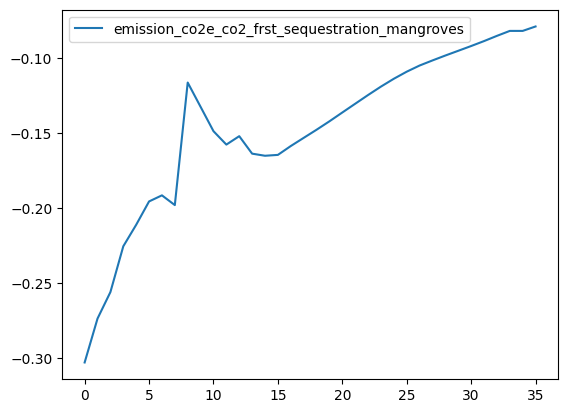

In [572]:
df_out[[x for x in df_out if "emission_co2e_co2_frst_sequestration_mangroves" in x]].plot()
#df_out[[x for x in df_out if "c_stock_frst_ag_mt_" in x]].plot()
#df_out["c_stock_frst_total_mt"].plot()

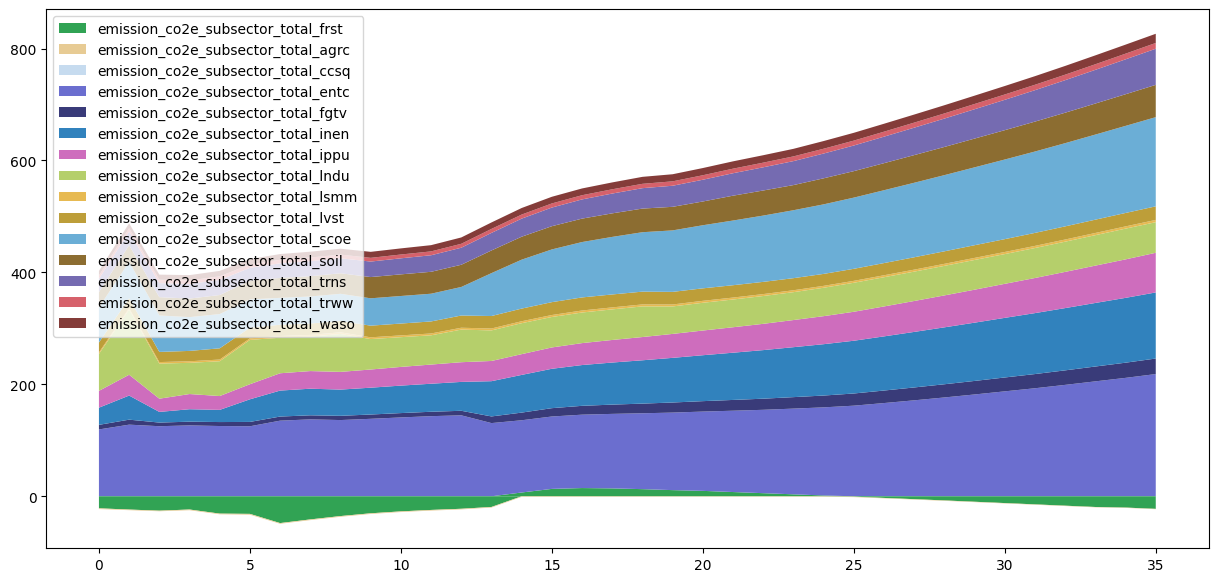

In [574]:
import sisepuede.visualization.plots as svp

fig, ax = plt.subplots(figsize = (15, 7))

svp.plot_emissions_stack(
    df_out,
    matt,
    figtuple = (fig, ax, )
)

ax.legend()


In [ ]:
dataset_manure = do.DatasetFAO(
    '/Users/usuario/SISEPUEDE_DATA_REPOSITORY/FAOSTAT2024/Environment_LivestockManure_E_All_Data_(Normalized)/Environment_LivestockManure_E_All_Data_(Normalized).csv',
    #'/Users/usuario/SISEPUEDE_DATA_REPOSITORY/FAOSTAT2024/Production_Crops_Livestock_E_All_Data_(Normalized)/Production_Crops_Livestock_E_All_Data_(Normalized).csv'
)

In [ ]:
df_input_lurf1[[x for x in df_input_lurf1 if "ef_lsmm_direct_management_" in x]].iloc[0]





In [ ]:
49.47*matt.get_gwp("ch4")
df_input_lurf2 = df_input_lurf1.copy()
cols = [x for x in df_input_lurf1.columns if "frac_lvst_mm_cattle" in x]#].iloc[0]
df_input_lurf2[cols] = 0 
fields_mm_frac_to_fert = [x for x in df_input_lurf1 if "frac_lsmm_manure_to_fertilizer_" in x]
#df_input_lurf2[fields_mm_frac_to_fert] = 0
#df_input_lurf2["frac_lvst_mm_cattle_dairy_deep_bedding"] = 1
#df_input_lurf2["frac_lvst_mm_cattle_nonairy_deep_bedding"] = 1


df_try2 = models(df_input_lurf2, include_nemo_fuel_production = False, )



In [ ]:
df_try2[[x for x in df_try2 if x.startswith("emission_co2e") and ("n2o" in x) and ("lsmm" in x)]].iloc[0]#()
#df_try2["emission_co2e_subsector_total_waso"].head()

In [ ]:
df_try2[[x for x in df_try2 if x.startswith("emission_co2e") and ("n2o" in x) and ("lsmm" in x)]].iloc[0]#()
#df_try2["emission_co2e_subsector_total_waso"].head()

In [ ]:
df_out["emission_co2e_subsector_total_lsmm"].head()




In [ ]:
df_input[[x for x in df_input if ("lsmm" in x) and ("_n2o_" in x)]].iloc[0]

In [ ]:
df_input_lurf1.shape
df_input_lurf1["frac_inen_energy_cement_coal"]
df_input_lurf1["elasticity_ippu_cement_production_to_gdp"].plot()

In [ ]:
df_out = models(
    df_input_lurf1, 
    include_nemo_fuel_production = True,
    time_periods_base = np.arange(12),
    #time_periods_run = np.arange(12),
    verbose = True, 
)

In [ ]:
df = sm.mep.df_tmp
df

In [ ]:
df = sm.mep.df_out2
df[
    df["f"].isin(["fuel_electricity"])
    & df["y"].isin([1020])
]

In [ ]:
df = sm.mep.df_out2
df[
    df["f"].isin(["fuel_electricity"])
    & df["y"].isin([1020])
]

In [ ]:
df = sm.mep.df_out2
df[
    df["f"].isin(["fuel_electricity"])
    & df["y"].isin([1020])
]




In [ ]:
mp.modvar_entc_tag_biomass_replacement_tech

In [ ]:
mp.model_attributes.extract_model_variable(#
    df_input_lurf1,
    mp.modvar_entc_tag_biomass_replacement_tech,
    expand_to_all_cats = True,
    return_type = "data_frame",
    var_bounds = (0, 1),
)

In [ ]:
self.merge_array_var_partial_cat_to_array_all_cats(
                np.array(out), 
                modvar, 
                missing_vals = all_cats_missing_val,
            )

In [ ]:
#df_input_lurf1[[x for x in df_input_lurf1 if "min_share" in x]].head()
df_pivot


In [ ]:
arr_shifter.sum(axis = 1)

In [ ]:
# 
df_pivot


In [ ]:
mp = models.model_enerprod
mp.cat_enfu_elec

In [ ]:
engine = sqlalchemy.create_engine(f"sqlite:///{models.fp_nemomod_temp_sqlite_db}")
engine

In [ ]:
engine = sqlalchemy.create_engine(f"sqlite:///{models.fp_nemomod_temp_sqlite_db}")
models.model_enerprod(
    sm.dfi, 
    engine = engine, 
    time_periods_base = np.arange(12), 
    verbose = True,
)


In [ ]:
df_out = models(
    df_input_lurf1, 
    include_nemo_fuel_production = True,
    time_periods_base = np.arange(12),
    #time_periods_run = np.arange(12),
)

In [ ]:
df_out = models(
    df_input_lurf1, 
    include_nemo_fuel_production = False,
    time_periods_base = np.arange(12),
)
df_in = sf.match_df_to_target_df(
    df_input_lurf1,
    df_out,
    [time_periods.field_time_period],
    overwrite_only = False,
)

df, v1, v2  = models.model_enerprod.get_biomass_components(df_in, )
plt.plot(v2)

In [ ]:
import sisepuede.utilities._sql as squ

In [ ]:


df = models.model_enerprod.format_nemomod_table_emissions_activity_ratio(df_in, )
df = df.get("EmissionActivityRatio")
df[
    df["t"].isin(["pp_biomass"])
    & df["e"].isin(["co2"])
]


In [ ]:

df = models.model_enerprod.get_integrated_waste_emissions_activity_ratio(df_in, )
df

In [ ]:

#df, vec, ef = models.model_enerprod.format_nemomod_table_emissions_activity_ratio(df_in, )

In [ ]:
[x for x in dir(matt) if "get_variable" in x]

In [ ]:
matt.get_variable_characteristic(
    models.model_afolu.modvar_entc_fuel_constraint_crop_residues,
    "unit_energy"
)

In [ ]:
um_energy = matt.get_unit("energy")
um_energy.convert("gj", "mmbtu")

In [ ]:
df_input_lurf1[[x for x in df_input_lurf1.columns if "waste" in x and "enfu" in x]]

In [ ]:
# df_input_lurf1[[x for x in df_input_lurf1.columns if "waste" in x and "enfu" in x]]
df_input_lurf1["cost_enfu_fuel_waste_usd_per_mmbtu"]



In [ ]:
df_input_lurf1[["nemomod_entc_variable_cost_pp_waste_incineration_usd_per_mwh"]]

In [ ]:
df_input_lurf1[["nemomod_entc_variable_cost_pp_waste_incineration_usd_per_mwh"]]

In [ ]:
#df_out[[x for x in df_out.columns if "energy_demand_enfu_" in x and "ammonia" in x]]
importlib.reload(sm.mec)
importlib.reload(sm)
models2 = sm.SISEPUEDEModels(
    matt,
    allow_electricity_run = False,
    initialize_julia = False,
)

#models.model_enercons.project_enfu_production_and_demands(df_mergein)
df_out = models2(df_input_lurf1, )

df_mergein = sf.match_df_to_target_df(
    df_input_lurf1,
    df_out,
    fields_index = ["time_period"],
    overwrite_only = False,
)

In [ ]:
models2.model_enercons.get_industrial_ammonia_fuel_demand(
    df_mergein,
    units_energy_specification = "EJ",
) 

In [ ]:
df_out

In [ ]:
sm.dfr

In [ ]:
sm.df_return1[1]

In [ ]:
# df_out[[x for x in df_out.columns if "entc" in x]]
df_out[[x for x in df_out.columns if "ammonia" in x]]




In [ ]:
df_try1[[x for x in df_out.columns if "entc" in x]].plot()





In [ ]:
#df_out["fuel_available_entc_biomass_fuelwood_pp_biomass_pj"]
svp.plot_emissions_stack(df_out, matt, )

In [ ]:
import sisepuede.visualization.plots as svp

In [ ]:
[
    x for x in matt.all_variable_fields_output
    if (
        (
            ("agrc" in x)
            or ("soil" in x)
            or ("lsmm" in x)
            or ("lvst" in x)
            or ("frst" in x)
            or ("lndu" in x)
        )
        and (
            x not in df_try1.columns
        )
    )
]



In [ ]:
model_afolu.arrays_agrc.arr_agrc_residue_final_use_field

In [ ]:
(
    model_afolu
    .modvar_frst_emissions_co2_sequestration_potential
    .get_from_dataframe(
        df_try1
    )
)

In [ ]:
df_try1[[x for x in df_try1.columns if "_stock" in x]]
df_try1[["c_stock_frst_total_mt", "c_stock_frst_removals_total_mt"]].plot()

In [ ]:
df_try1[[x for x in df_try1.columns if "_stock" in x]]
df_try1[["c_stock_frst_total_mt", "c_stock_frst_removals_total_mt"]].plot()

In [ ]:
df_try1[[x for x in df_try1.columns if "charcoal" in x]]

In [ ]:
#df_input_lurf1[[x for x in df_input_lurf1 if "fert" in x]].iloc[0]\
?mafl.suc.TimeSeriesSimplexShifter.shift_mass_scalar_vectors

In [ ]:
[x for x in df_try1 if "entc" in x]

In [ ]:
[x for x in df_try1 if "biomass" in x]

In [ ]:
k = 10
df_try1[0][k].plot()
cats = matt.get_variable_categories(
    matt.get_variable(":math:\\text{CO}_2 Emissions from Biomass Carbon Stock Changes")
)

"|".join([f"``{x}``" for x in model_afolu.attr_agrc.key_values if x not in cats])



In [ ]:
df_try1[0][10].iloc[-1]
emit = 58.653455
rmv = 41.694992

model_afolu.factor_c_to_co2*0.5

In [ ]:
df_try1[0][10].plot()


In [ ]:
df_try1[0][5].plot()
cats = matt.get_variable_categories(
    matt.get_variable(":math:\\text{CO}_2 Emissions from Biomass Carbon Stock Changes")
)

"|".join([f"``{x}``" for x in model_afolu.attr_agrc.key_values if x not in cats])



In [ ]:
# 'arr_agrc_residue_final_use_burned'
# 'arr_agrc_residue_final_use_energy'
# 'arr_agrc_residue_final_use_feed'
# 'arr_agrc_residue_final_use_field'
v = model_afolu.arrays_agrc.arr_agrc_residue_final_use_field[0]
[model_afolu.attr_agrc.key_values[x] for x in np.where(v > 0)[0]]


In [ ]:
df_seq

In [ ]:
importlib.reload(sf)
sf.bounded_logistic_on_uniform_arr(
    np.array([0.3, 0.7, 0.9]),
    0.6,
    0.3,
    window_logistic = (-2, 3),
)

In [ ]:
_MODVARS_TARGET = [
    "Initial Above Ground Biomass Stock Factor",
    "Forest Above Ground Biomass Growth Rate",
    "Land Use Above Ground Biomass Growth Rate",
    "Young Secondary Forest Above Ground Biomass Growth Rate"
]

tables_drop = []
for modvar in _MODVARS_TARGET:
    for tt in construct.table_types:
        for bt in construct.variable_bounds_return_type:
            nm = construct.get_output_db_table_name(
                modvar,
                tt,
                bound_type = bt,
            )

            if nm in construct.output_database.all_tables:
                tables_drop.append(nm)

In [ ]:
df_input2, _ = model_afolu.model_socioeconomic(df_input, )
bcl, *_ = model_afolu.get_bcl(df_input2, )

In [ ]:
df_input[[x for x in df_input.columns if "dead" in x]]
df_input[[x for x in df_input.columns if "buffer" in x]]






In [ ]:
#import sisepuede.models.biomass_carbon_ledger as bcl

In [ ]:
[x for x in dir(bcl) if "dead" in x]
bcl.arr_frac_biomass_dead_storage
buffer = bcl.arr_frac_biomass_buffer[0, 0]
dead_storage = bcl.arr_frac_biomass_dead_storage[0, 0]

buffer


In [ ]:
df_try1[0][19].plot.area(legend = True, )

In [ ]:
model_afolu.modvar_lndu_area_converted

In [ ]:
len(df_try1[0])
df_try1[0][20].plot.area(legend = True, )

In [ ]:
len(df_try1[0])
df_try1[0][20].plot.area(legend = True, )

In [ ]:
v1 = np.arange(10)
arr = np.random.rand(10, 5)
arr

In [ ]:
v1

In [ ]:
sf.do_array_mult(arr, v1, )

In [ ]:
lde.ind_crop_imports_cereals, lde.ind_crop_imports_non_cereals
 

#dir(lde)

In [ ]:
sf.check_row_sums(
    np.zeros((5, 6, )),
    thresh_correction = None,
)

In [ ]:
data_fb = do.DatasetFAO(
    #"/Users/usuario/SISEPUEDE_DATA_REPOSITORY/FAOSTAT2024/FoodBalanceSheets_E_All_Data_(Normalized)/FoodBalanceSheets_E_All_Data_(Normalized).csv"
    "/Users/usuario/SISEPUEDE_DATA_REPOSITORY/FAOSTAT2024/Inputs_FertilizersNutrient_E_All_Data_(Normalized)/Inputs_FertilizersNutrient_E_All_Data_(Normalized).csv"
)


In [ ]:
data_fb.get_subset(
    area = "Mexico",
    #element = "Manure management (manure treated, N content)",
    year = 2021
)#["Element"].unique()

In [ ]:
plt.style.use("dark_background", )

fig, ax = plt.subplots(2, 1, figsize = (12, 14))
df_try1[1][1].plot(ax = ax[0], color = "gold", linewidth = 3, )
df_try1[1][2].plot(ax = ax[0], color = "forestgreen", linewidth = 3, )
ax[0].set_ylim(0, 125)
#df_try1[1][2].plot(ax = ax, )
#ax.plot(model_afolu.arrays_agrc.arr_agrc_residue_final_use_energy/82900, )


df_plot = df_try1[0][0]
df_plot[[x for x in df_plot.columns if x.startswith("c_stock_frst")]].plot(
    ax = ax[1],
    linewidth = 3, 
)

In [ ]:
df_try1[0][6]["emission_co2e_co2_frst_sequestration_secondary"].plot()

In [ ]:
vec_test5 = df_try1[0][0]["c_stock_frst_ag_mt_primary"].to_numpy()

In [ ]:
plt.plot(vec_test2, )
plt.plot(vec_test, )
plt.plot(vec_test3, )
plt.plot(vec_test4, )
plt.plot(vec_test5, )

In [ ]:
vec_test2 = df_try1[0][0]["c_stock_frst_ag_mt_primary"].to_numpy()

In [ ]:
vec_test = df_try1[0][0]["c_stock_frst_ag_mt_primary"].to_numpy().copy()

In [ ]:
-5.551115123125783e-17 < -1e-8

In [ ]:
?mafl.suc.TimeSeriesSimplexShifter

In [ ]:
dict_subsec_to_modvar = dict(
    (k, v.get("energy_demand"))
    for k, v in (
        self
        .model_enercons
        .get_enfu_dict_subsectors_to_energy_variables()[0]
        .items()
    )
)

In [ ]:
d

In [ ]:


arr_target_allocations = dict_cat_to_fuel_shares.get("residential")

vec_scalar = 1 + 5*sf.ramp_vector(
    df_input.shape[0],
    alpha_logistic = 1.0,
    r_0 = 11,
)
dict_vec_scalars = {ind_biomass: vec_scalar, }




In [ ]:
import sisepuede.utilities._classes as suc
importlib.reload(suc)







df_new = get_ilu_fuel_shifts_from_biomass(model_afolu,
    df_input,
    vec_scalar,
)



In [ ]:
df_new["frac_inen_energy_agriculture_and_livestock_solid_biomass"]
df_new[[x for x in df_new.columns if x.startswith("frac_inen_energy_agriculture_and_livestock")]]

In [ ]:
df_input["frac_inen_energy_agriculture_and_livestock_gasoline"]

In [ ]:
arr_end_states

In [ ]:
dict_subsec_to_modvar = dict(
            (k, v.get("energy_demand"))
            for k, v in (
                self
                .model_enercons
                .get_enfu_dict_subsectors_to_energy_variables()[0]
                .items()
            )
        )

In [ ]:
vec_1 = np.random.rand(5)
vec_2 = np.random.rand(5)
vec_1

In [ ]:
v_out = sf.vector_limiter(
    [vec_1, vec_2],
    (0, 1.2)
)

In [ ]:
1.2*vec_2[1]/(vec_1[1] + vec_2[1])

In [ ]:
x = np.random.rand(5, 2)
xf = x.flatten(order = "F", )

In [ ]:
xs = np.split(xf, 2)
np.concatenate(xs).reshape((5, 2), order = "F")

In [ ]:
importlib.reload(sf)
sf.vector_limiter(x, (0, 1))

In [ ]:
x#(x.transpose()/x.sum(axis = 1)).transpose()

In [ ]:
vec_1 + vec_2

In [ ]:
sum(v_out,)

In [ ]:
df_input_lurf1[[x for x in df_input_lurf1.columns if x.startswith("pop_lvst")]]

In [ ]:
plt.plot(model_afolu.)

In [ ]:
mat

In [ ]:
i = 0
mat = model_afolu.lde.display_as_matrix(mafl.dict_sol_prelim.get(i, ).x.astype(int), )
mat.sum(axis = 0, )

In [ ]:
df1.plot.area()

In [ ]:
df0.tail()


In [ ]:
df_input[[x for x in df_input.columns if "pij_lndu_forests_primary_to" in x]]

In [ ]:
# 1
model_afolu.arr_lvst_pop



In [ ]:
# 1
df = pd.DataFrame(model_afolu.arr_land_use, columns = model_afolu.attr_lndu.key_values)
df.plot.area()
df["croplands"]

In [ ]:
model_afolu.arrs_transitions_adj

In [ ]:
df = pd.DataFrame(model_afolu.arr_land_use, columns = model_afolu.attr_lndu.key_values)
df.plot.area()
df["pastures"]

In [ ]:
importlib.reload(ma)

importlib.reload(mafl.suo)
importlib.reload(mafl.npp)
importlib.reload(mafl.coll_arrays)
importlib.reload(mafl)

model_afolu = mafl.AFOLU(
    matt, 
    npp_curve = "sem", 
    npp_include_primary_forest = True,
)

model_afolu._initialize_array_classes(df_input, )

# TEST ERROR THROWING:
# df_input2 = df_input.copy().get([x for x in df_input.columns if not x.startswith("elasticity_lvst")])
# model_afolu._initialize_array_classes(df_input, )



df_afolu_trajectories = df_input.copy()
df_afolu_trajectories["time_period"] = df_afolu_trajectories["time_period"].astype(int)

# make sure socioeconomic variables are added and
df_afolu_trajectories, df_se_internal_shared_variables = model_afolu.model_socioeconomic.project(
    df_afolu_trajectories,
)

# check that all required fields are contained—assume that it is ordered by time period
model_afolu.check_df_fields(df_afolu_trajectories)
(
    dict_dims, 
    df_afolu_trajectories, 
    n_projection_time_periods, 
    projection_time_periods
) = model_afolu.model_attributes.check_projection_input_df(
    df_afolu_trajectories, 
    True, 
    True, 
    True
)

# check integrated variables for HWP
dict_check_integrated_variables = model_afolu.model_attributes.check_integrated_df_vars(
    df_afolu_trajectories, 
    model_afolu.dict_integration_variables_by_subsector, 
    "all"
)


##  CATEGORY INITIALIZATION

# pycat_ABRV is used to access the category elements (in context of 
# variable schema) in the attribute tables
pycat_lndu = model_afolu.model_attributes.get_subsector_attribute(
    model_afolu.subsec_name_lndu, 
    "pycategory_primary_element"
)
pycat_lsmm = model_afolu.model_attributes.get_subsector_attribute(
    model_afolu.subsec_name_lsmm, 
    "pycategory_primary_element"
)
pycat_soil = model_afolu.model_attributes.get_subsector_attribute(
    model_afolu.subsec_name_soil, 
    "pycategory_primary_element"
)

# attribute tables
attr_agrc = model_afolu.model_attributes.get_attribute_table(model_afolu.subsec_name_agrc)
attr_frst = model_afolu.model_attributes.get_attribute_table(model_afolu.subsec_name_frst)
attr_lndu = model_afolu.model_attributes.get_attribute_table(model_afolu.subsec_name_lndu)
attr_lsmm = model_afolu.model_attributes.get_attribute_table(model_afolu.subsec_name_lsmm)
attr_lvst = model_afolu.model_attributes.get_attribute_table(model_afolu.subsec_name_lvst)
attr_soil = model_afolu.model_attributes.get_attribute_table(model_afolu.subsec_name_soil)


##  ECON/GNRL VECTOR AND ARRAY INITIALIZATION

# get some vectors
vec_gdp = model_afolu.model_attributes.extract_model_variable(#
    df_afolu_trajectories, 
    model_afolu.model_socioeconomic.modvar_econ_gdp,  
    return_type = "array_base",
)

vec_gdp_per_capita = model_afolu.model_attributes.extract_model_variable(#
    df_afolu_trajectories, 
    model_afolu.model_socioeconomic.modvar_econ_gdp_per_capita, 
    return_type = "array_base",
)

vec_hh = model_afolu.model_attributes.extract_model_variable(#
    df_afolu_trajectories, 
    model_afolu.model_socioeconomic.modvar_grnl_num_hh, 
    return_type = "array_base",
)

vec_pop = model_afolu.model_attributes.extract_model_variable(#
    df_afolu_trajectories, 
    model_afolu.model_socioeconomic.modvar_gnrl_pop_total, 
    return_type = "array_base",
)

vec_rates_gdp = np.array(df_se_internal_shared_variables["vec_rates_gdp"].dropna())
vec_rates_gdp_per_capita = np.array(df_se_internal_shared_variables["vec_rates_gdp_per_capita"].dropna())


##  INPUT/OUTPUT INITIALIZATION
# initialize arrays
model_afolu._initialize_arrays_from_df(df_afolu_trajectories, )

# initialize output DataFrame as list
df_out = [df_afolu_trajectories[model_afolu.required_dimensions].copy()]




#################################
#    SOME AGRICULTURE ARRAYS    #
#################################

tup_residue_info = model_afolu.get_agrc_residue_vars(
    df_afolu_trajectories, 
)


# get target integreated land use unit variables
modvar_ilu_area, modvar_ilu_mass = model_afolu.get_modvars_for_unit_targets_ilu()

# area of the country + the applicable scalar used to convert outputs
vec_area = model_afolu.model_attributes.extract_model_variable(#
    df_afolu_trajectories,
    model_afolu.model_socioeconomic.modvar_gnrl_area,
    return_type = "array_base",
)

scalar_lndu_input_area_to_output_area = model_afolu.model_attributes.get_scalar(
    model_afolu.model_socioeconomic.modvar_gnrl_area, 
    "area"
)


# initial land use area in terms of 
area_init = vec_area[0]
vec_modvar_lndu_initial_frac = model_afolu.arrays_lndu.arr_lndu_initial_frac[0]
vec_modvar_lndu_initial_area = vec_modvar_lndu_initial_frac*area_init

# transition matrices and carbon factors
(
    arrs_lndu_q_unadj,
    arrs_lndu_c_agb, 
    arrs_lndu_c_bgb,
    arr_lndu_c_init_agb,
) = model_afolu.get_markov_matrices(
    df_afolu_trajectories, 
    n_tp = n_projection_time_periods,
    return_c_stock_conversion_factors = True,
    modvar_target_units_area = modvar_ilu_area,
    modvar_target_units_mass = modvar_ilu_mass,
)

# land use reallocation factor
vec_lndu_reallocation_factor = model_afolu.arrays_lndu.arr_lndu_reallocation_factor

# area constraints by class
(
    arr_lndu_constraints_inf,
    arr_lndu_constraints_sup,
) = model_afolu.get_lndu_class_bounds(
    vec_modvar_lndu_initial_area,
)





(
    # agrc vars
    arr_agrc_domestic_demand_nonfeed_unadj,
    arr_agrc_exports_unadj,
    arr_agrc_imports_nonfeed_unadj,
    arr_agrc_production_nonfeed_unadj,
    arr_agrc_yf,
    vec_agrc_frac_cropland_area,
    vec_agrc_frac_production_wasted,
    vec_agrc_init_domestic_production_feed,
    vec_agrc_init_imports_feed_unadj,
    # lndu vars
    total_yield_init_lndu_pasture_avg,
    total_yield_init_lndu_pasture_sup,
    vec_lndu_yf_pasture_avg,
    vec_lndu_yf_pasture_sup,
    # lvst vars
    arr_lvst_annual_feed_per_capita,
    arr_lvst_domestic_demand_unadj,
    arr_lvst_exports_unadj,
    arr_lvst_imports_unadj,
    arr_lvst_domestic_production_unadj,
    vec_lvst_production_init,
    vec_lvst_total_feed_required,
) = model_afolu.project_agrc_lvst_integrated_demands(
    df_afolu_trajectories,
    vec_modvar_lndu_initial_area,
    vec_pop, 
    vec_rates_gdp_per_capita,
)


In [ ]:
# args for integrated model
#df_afolu_trajectories
vec_initial_area = vec_modvar_lndu_initial_area
arrs_transitions = arrs_lndu_q_unadj
arr_c_lndu_agb = arr_lndu_c_init_agb
arrs_c_agb = arrs_lndu_c_agb
arrs_c_bgb = arrs_lndu_c_bgb
arr_agrc_production_nonfeed_unadj = arr_agrc_production_nonfeed_unadj
arr_agrc_yield_factors = arr_agrc_yf
arr_lndu_constraints_inf = arr_lndu_constraints_inf
arr_lndu_constraints_sup = arr_lndu_constraints_sup
# arr_lndu_yield_i_reqd_lvst_j_init,
# factor_lndu_init_avg_consumption_pstr,
arr_lvst_annual_feed_per_capita = arr_lvst_annual_feed_per_capita
arr_lvst_dem = arr_lvst_domestic_production_unadj
tup_residue_info = tup_residue_info
vec_agrc_frac_cropland_area = vec_agrc_frac_cropland_area
vec_lndu_yrf = vec_lndu_reallocation_factor
vec_lvst_scale_cc = np.ones(len(df_afolu_trajectories))# vec_lvst_carry_capacity_scale
vec_gnrl_area = vec_area
n_tp = n_projection_time_periods
vec_rates_gdp = vec_rates_gdp
prohibit_forest_transitions = None

In [ ]:
t0 = time.time()

# check shapes
n_tp = n_tp if (n_tp != None) else model_afolu.n_time_periods

model_afolu.check_markov_shapes(arrs_transitions, "arrs_transitions", )
model_afolu.check_markov_shapes(arrs_c_agb, "arrs_efs", )
model_afolu.check_markov_shapes(arrs_c_bgb, "arrs_efs", )

# get attributes
attr_agrc = model_afolu.model_attributes.get_attribute_table(model_afolu.subsec_name_agrc, )
attr_lndu = model_afolu.model_attributes.get_attribute_table(model_afolu.subsec_name_lndu, )
attr_lvst = model_afolu.model_attributes.get_attribute_table(model_afolu.subsec_name_lvst, )

# set some commonly called attributes and indices in arrays
inds_frst = [
    attr_lndu.get_key_value_index(x) 
    for x in model_afolu.dict_cats_lndu_to_cats_frst.keys()
]
m = attr_lndu.n_key_values

# scalar to convert input area values to biomass carbon ledger values
modvar_bcl_area, modvar_bcl_mass = model_afolu.get_modvars_for_unit_targets_bcl() 
modvar_ilu_area, modvar_ilu_mass = model_afolu.get_modvars_for_unit_targets_ilu()

scalar_int_area_to_bcl_area = model_afolu.model_attributes.get_variable_unit_conversion_factor(
    modvar_ilu_area,
    modvar_bcl_area,
    "area",
)

scalar_int_mass_to_bcl_mass = model_afolu.model_attributes.get_variable_unit_conversion_factor(
    modvar_ilu_mass,
    modvar_bcl_mass,
    "mass",
)

prohibit_forest_transitions = (
    model_afolu.prohibit_forest_transitions
    if not isinstance(prohibit_forest_transitions, bool)
    else prohibit_forest_transitions
)


# get some information used to estimate residues, which have to be included in-line 
(
    arr_agrc_regression_b,      # intercept (mass/area)
    arr_agrc_regression_m,      # slope (dimensionless)
    dict_agrc_residue_pathways, # where residues go
    scalar_agrc_mass_b_to_bcl,  # convert agrc mass to bcl
    scalar_agrc_regression_b,   # into ILU units (mass/area)
) = tup_residue_info

In [ ]:
##  INITIALIZE OUTPUT ARRAYS AND VARIABLES

# intilize land use, land converted, emissions, and adjusted transitions
arr_agrc_crop_drymatter_above_ground = np.zeros((n_tp, attr_agrc.n_key_values))
arr_agrc_crop_drymatter_per_unit = np.zeros((n_tp, attr_agrc.n_key_values))
arr_agrc_frac_cropland = np.array([vec_agrc_frac_cropland_area for k in range(n_tp)])
arr_agrc_net_import_increase = np.zeros((n_tp, attr_agrc.n_key_values))
arr_agrc_change_to_net_imports_lost = np.zeros((n_tp, attr_agrc.n_key_values))

# get yield
arr_agrc_yield = np.array([
    (vec_initial_area[model_afolu.ind_lndu_crop]*vec_agrc_frac_cropland_area*arr_agrc_yield_factors[0]) 
    for k in range(n_tp)
])

# land use variables
arr_emissions_conv_ag = np.zeros((n_tp, attr_lndu.n_key_values))
arr_emissions_conv_bg = np.zeros((n_tp, attr_lndu.n_key_values))
arr_emissions_conv_agb_matrices = np.zeros(arrs_transitions.shape)
arr_emissions_conv_bgb_matrices = np.zeros(arrs_transitions.shape)
arr_land_use = np.array([vec_initial_area for k in range(n_tp)])

arrs_land_conv = np.zeros((n_tp, attr_lndu.n_key_values, attr_lndu.n_key_values))
arrs_transitions_adj = np.zeros(arrs_transitions.shape)


# livestock variables
arr_lvst_dem_adj = arr_lvst_dem.copy().astype(int)
arr_lvst_pop_adj = arr_lvst_dem.copy().astype(int)
arr_lvst_net_import_increase = np.zeros((n_tp, attr_lvst.n_key_values))
arr_lvst_change_to_net_imports_lost = np.zeros((n_tp, attr_lvst.n_key_values))

arrs_yields_per_livestock = np.array([arr_lvst_annual_feed_per_capita for k in range(n_tp)])

vec_lvst_aggregate_animal_mass = np.zeros(n_tp, )
vec_lvst_dem_gr_iterator = np.ones(len(arr_lvst_dem[0]))


# initialize the ledgers
ledger = model_afolu.get_bcl(
    df_afolu_trajectories, 
    vec_rates_gdp = vec_rates_gdp, 
)

ledger_mangroves = model_afolu.get_bcl(
    df_afolu_trajectories, 
    mangroves = True, 
    vec_rates_gdp = vec_rates_gdp, 
)


##  INITIALIZE VARIABLES

arr_agrc_bagasse_factor = model_afolu.arrays_agrc.arr_agrc_bagasse_yield_factor
arr_agrc_frac_feed = model_afolu.arrays_agrc.arr_agrc_frac_animal_feed
arr_c_lndu_ratio_bg_to_ag = model_afolu.arrays_lndu.arr_lndu_biomass_stock_ratio_bg_to_ag
arr_dm_frac_crops = model_afolu.arrays_agrc.arr_agrc_frac_dry_matter_in_crop
arr_lndu_frac_increasing_net_exports_met = model_afolu.arrays_lndu.arr_lndu_frac_increasing_net_exports_met
arr_lndu_frac_increasing_net_imports_met = model_afolu.arrays_lndu.arr_lndu_frac_increasing_net_imports_met

# livestock
arr_lvst_mass_per_animal = (
    model_afolu.arrays_lvst.arr_lvst_animal_mass
    * model_afolu.model_attributes.get_variable_unit_conversion_factor(
        model_afolu.modvar_lvst_animal_mass,
        modvar_ilu_mass,
        "mass",
    )
)

factor_dietary_mass_balance_adjustment = 1.0

vec_lvst_aggregate_animal_mass[0] = np.dot(arr_lvst_dem[0], arr_lvst_mass_per_animal[0])

In [ ]:
x = vec_initial_area
i = 0

In [ ]:
type(res)

In [ ]:
# check transition matrix index
i_tr = i if (i < len(arrs_transitions)) else len(arrs_transitions) - 1
if i_tr != i:
    model_afolu._log(
        f"No transition matrix found for time period {model_afolu.time_periods[i]}; using the matrix from period {len(arrs_transitions) - 1}.",
        type_log = "warning"
    )


##  GET PROJECTED (UNADJUSTED) LAND USE PREVALENCE

x_proj_unadj = np.dot(x, arrs_transitions[i_tr])

# crop values
area_crop_cur = x[model_afolu.ind_lndu_crop]
area_crop_proj = x_proj_unadj[model_afolu.ind_lndu_crop]
vec_agrc_cropland_area_proj = area_crop_proj*arr_agrc_frac_cropland[i]

# pasture values
area_pstr_cur = x[model_afolu.ind_lndu_pstr]
area_pstr_proj = x_proj_unadj[model_afolu.ind_lndu_pstr]

#HERE123
lurf = vec_lndu_yrf[i]



# get 

In [ ]:
path = "/Users/usuario/SISEPUEDE_DATA_REPOSITORY/FAOSTAT2024/Trade_CropsLivestock_E_All_Data_(Normalized)/Trade_CropsLivestock_E_All_Data_(Normalized).csv"
dataset_trade = do.DatasetFAO(path )


In [ ]:
x = np.zeros(16)

def func(vec, i, val):
    vec[i] = val

    return None

func(x, 1, 0.9)
func(x, 8, 0.18)

x



In [ ]:
?ledger

In [ ]:
importlib.reload(ma)

importlib.reload(mafl.suo)
importlib.reload(mafl.npp)
importlib.reload(mafl.coll_arrays)
importlib.reload(mafl)

model_afolu = mafl.AFOLU(
    matt, 
    npp_curve = "sem", 
    npp_include_primary_forest = True,
)

model_afolu._initialize_array_classes(df_input, )
lde = model_afolu.lde

In [ ]:
importlib.reload(ma)

importlib.reload(mafl.suo)
importlib.reload(mafl.npp)
importlib.reload(mafl.coll_arrays)
importlib.reload(mafl)

model_afolu = mafl.AFOLU(
    matt, 
    npp_curve = "sem", 
    npp_include_primary_forest = True,
)

model_afolu._initialize_array_classes(df_input, )
lde = model_afolu.lde
# TEST ERROR THROWING:
# df_input2 = df_input.copy().get([x for x in df_input.columns if not x.startswith("elasticity_lvst")])
# model_afolu._initialize_array_classes(df_input, )





factor_carrying_capacity = 1

i = 0
vec_lvst_pop = arr_lvst_pop_adj[i]
print(vec_lvst_pop)
#
#  MAY NEED TO PASS GRAZING RATE TO ALL AFTER INIT;
# (!) get graze rate (ratio_yield) at initial run
#     use this to set supply availability for subsequent runs 
#


graze_rate = None
vec_agrc_frac_imports_for_lvst = None

(
    sol_init_0,
    sol_new_0,
    lvst_dietary_mass_factor, 
    ratio_yield,
    vec_import_fracs_for_lvst,
    vec_lde_carrying_capacity,
    vec_lde_supply_carrying_capacity,
    vec_lde_supply, 
) = model_afolu.get_lde_lvst_land_demands(
    i,
    vec_lndu_yf_pasture_avg[i],
    0.,#1.0,
    vec_agrc_cropland_area_proj,
    arr_agrc_regression_b[i],
    arr_agrc_regression_m[i],
    arr_agrc_yield_factors[i],
    x,
    arr_lvst_annual_feed_per_capita[i],
    vec_lvst_pop,
    lvst_dietary_mass_factor = 1.0,     
    vec_agrc_frac_imports_for_lvst = vec_agrc_frac_imports_for_lvst,
)

if i == 0:
    graze_rate = ratio_yield
    vec_agrc_frac_imports_for_lvst = vec_import_fracs_for_lvst



i = 1
vec_lvst_pop = arr_lvst_pop_adj[i]
print(vec_lvst_pop)
(
    sol_init_1,
    sol_new_1,
    lvst_dietary_mass_factor, 
    ratio_yield,
    vec_import_fracs_for_lvst,
    vec_lde_carrying_capacity,
    vec_lde_supply_carrying_capacity,
    vec_lde_supply, 
) = model_afolu.get_lde_lvst_land_demands(
    i,
    vec_lndu_yf_pasture_avg[i]*graze_rate,
    1.0,#1.0,
    vec_agrc_cropland_area_proj,
    arr_agrc_regression_b[i],
    arr_agrc_regression_m[i],
    arr_agrc_yield_factors[i],
    x2,
    arr_lvst_annual_feed_per_capita[i],
    vec_lvst_pop,
    lvst_dietary_mass_factor = 1.0,     
    vec_agrc_frac_imports_for_lvst = vec_agrc_frac_imports_for_lvst,
)




In [ ]:
[x for x in dir(sf) if "norm" in x]


In [ ]:
# graze_rate_practice = graze_rate*scalar_lvst_carrying_capacity
i = 0
area_target_pastures, vec_agrc_area_target_for_lvst = model_afolu.estimate_lde_lvst_new_lndu_demands(
    sol_init_0,
    vec_lndu_yf_pasture_avg[i]*graze_rate, 
    vec_agrc_cropland_area_proj,
    arr_agrc_frac_feed[i],
    vec_lde_supply,
    vec_lde_supply_carrying_capacity,
)

area_target_pastures, vec_agrc_area_target_for_lvst


In [ ]:
vec_agrc_area_target_for_lvst.astype(int)



In [ ]:
(vec_agrc_cropland_area_proj*arr_agrc_frac_feed[0]).astype(int)





In [ ]:
# shortcuts
arr_agrc_bagasse_factor = model_afolu.arrays_agrc.arr_agrc_bagasse_yield_factor
arr_agrc_frac_feed = model_afolu.arrays_agrc.arr_agrc_frac_animal_feed
arr_dm_frac_crops = model_afolu.arrays_agrc.arr_agrc_frac_dry_matter_in_crop
vec_agrc_frac_residue_for_feed = model_afolu.get_lde_fraction_residues_for_feed(i, )


##  INITIALIZE INPUTS 

vec_costs = model_afolu.get_lde_costs()

# get residue generation factors
vec_agrc_genfactor_residues, vec_lde_genfactor_residues = model_afolu.get_lde_vector_residue_genfactors(
    vec_agrc_area,
    arr_agrc_bagasse_factor[i],
    arr_dm_frac_crops[i],
    arr_agrc_frac_feed[i],
    arr_agrc_regression_b[i],
    arr_agrc_regression_m[i],
    arr_agrc_yield_factors[i],
)

vec_lvst_feed_demands = model_afolu.get_lde_vector_demand(
    arr_lvst_annual_feed_per_capita[i],
    arr_lvst_pop_adj[i],
    mass_balance_adjustment = 1.0,
)

# get the imports
_, vec_lde_imports = model_afolu.get_lde_crop_import_fracs(
    i, 
    vec_agrc_area*arr_agrc_yield_factors[i], 
)

# get supply
vec_lde_supply = model_afolu.get_lde_vector_supply(
    vec_lndu_yf_pasture_avg[i],   #
    vec_agrc_area,                # vec_agrc_cropland_area_proj,
    vec_agrc_genfactor_residues,  #
    arr_agrc_frac_feed[i],        #
    vec_lde_imports,              #
    arr_agrc_yield_factors[i],       # arr_agrc_yield_factors[i],
    vec_lndu_area,
)

args_bounds = model_afolu.get_lde_dietary_bounds(i = i, )
for_carrying_capacity = True

A_fb, b_fb = model_afolu.lde.get_constraint_coeffs_eq_lvst_feed_balance(
    vec_lvst_pop,
    for_carrying_capacity = for_carrying_capacity, 
)
A_df, b_df = model_afolu.lde.get_constraint_coeffs_leq_lvst_dietary_fractions(
    vec_lvst_feed_demands,
    *args_bounds,
    for_carrying_capacity = False, 
)

In [ ]:

model_afolu.lde.display_as_matrix(mafl.suo.AA[56]), b[56]

In [ ]:
ind = 56
model_afolu.lde.display_as_matrix(A_df[ind], )[7, ], b[ind]



In [ ]:
args_bounds


In [ ]:
vec_lvst_feed_demands.astype(int)


In [ ]:
model_afolu.lde.display_as_matrix(sol_init_0.x).sum(axis = 1).astype(int)

In [ ]:
# for estimating carrying capacity
# just use a scalar applied to population (or per animal feed requirements)
# maximize the scalar
#   - subject to supply leq constraint (land availability)
#   - subject to feed fractions
#   - no new allowed
#   - subject to sum of all row sums of feed nodes = y*demand_i

a = np.zeros(5)
a[0:-1]



In [ ]:
x1 + x2 <= d*f*y
x1/df + x2/df - y <= 0

In [ ]:
vec_lde_supply_carrying_capacity

In [ ]:
model_afolu.get_lde_mat_from_sol(sol, ).astype(int).sum(axis = 0)


In [ ]:
model_afolu.get_lde_mat_from_sol(sol_init, ).astype(int).sum(axis = 0)





In [ ]:
vec_lde_supply.astype(int)


In [ ]:
x#[model_afolu.ind_lndu_pstr]
x2 = x.copy()
ind = model_afolu.ind_lndu_pstr
val = x2[ind + 1]*0.057

x2[ind + 1] -= val
x2[ind] += val

In [ ]:
vec_lde_supply

In [ ]:
vec_lde_supply_carrying_capacity

In [ ]:
graze_rate

In [ ]:
x

In [ ]:
model_afolu.get_lde_mat_from_sol(sol_init, )[:,3].sum()

In [ ]:

    
    




mat_sol = lde.display_as_matrix(sol_init.x, )
mat_sol[:, [3, 7]].sum()

In [ ]:
vec_lde_supply_carrying_capacity


In [ ]:
vec_agrc_cropland_area_proj#*arr_agrc_frac_feed[i]
#arr_agrc_frac_feed[i]x
x

In [ ]:
vec_lde_supply_carrying_capacity



In [ ]:
model_afolu.get_lde_mat_from_sol(sol, ).astype(int)







In [ ]:
model_afolu.get_lde_mat_from_sol(sol, )[:, 3].sum()

[x for x in dir(model_afolu) if "inds" in x]


In [ ]:
np.nan_to_num(np.array([np.nan]), 0)

In [ ]:
lde = model_afolu.lde











In [ ]:
isinstance(sol, mafl.suo.sco.OptimizeResult)

In [ ]:
def get_carrying_capacity(model_afolu,
    sol: 'sco.OptimizeResult',
) -> np.ndarray:
    """Using a solution that gives 
    
    """

    # get the solution matrix
    mat_sol = model_afolu.lde.display_as_matrix(sol.x, )
    


In [ ]:
np.round(model_afolu.lde.display_as_matrix(sol.x))

In [ ]:
import afolu.crop_uses.modvar_crop_uses_diet_and_loss as cdl
importlib.reload(cdl)

reader_init_cdl = pu.InputsReader(
    path_pipeline.joinpath("afolu", "crop_uses", "config.yaml"),
    repository = repo,
    sisepuede_constructs = construct,
)


dict_out = cdl.main(
    inputs_reader = reader_init_cdl,
    return_behavior = "data_and_write",
    sisepuede_constructs = construct,
)

In [ ]:
t0 = time.time()
#vec_costs[4:7] = 1000000
sol = None
i = 0
lde = model_afolu.lde

while sol is None:
    
    res = model_afolu.lde.solve(
        vec_costs,
        vec_lvst_feed_demands*(1 - i/100),
        *args_bounds,
        vec_lde_genfactor_residues,
        vec_lde_supply,
        allow_new = False,
        method = "highs",
        options = {"disp": True, },
        stop_on_error = True,
        # vec_import_frac = vec_lde_import_fracs,
    )

    i += 1
    sol = res.x
        
i -= 1

mat = lde.display_as_matrix(sol)



In [ ]:
vec_lde_supply



In [ ]:
(mat.transpose()/mat.sum(axis = 1)).transpose()

In [ ]:
A_df, b_df = model_afolu.lde.get_constraint_coeffs_leq_lvst_dietary_fractions(
    vec_lvst_feed_demands,
    *args_bounds,
)

In [ ]:
ind = 25
A_df[ind].reshape((lde.m, lde.n)), b[ind]



In [ ]:
mat[:,[-3, -2, 1]]

In [ ]:
mat[3, [1, 4, 7]].sum()/vec_lvst_feed_demands[3]

int(vec_lvst_feed_demands[4])

In [ ]:
A, b = lde.get_constraint_coeffs_leq_lvst_feed_supply(
    vec_lde_genfactor_residues,
    vec_lde_supply,
)
ind = 2

A, b, G, h = lde.get_problem_components_constraints(
    True,
    vec_lvst_feed_demands,
    #vec_lde_import_fracs,
    *args_bounds,
    vec_lde_genfactor_residues,
    vec_lde_supply,
)
np.where(b - np.dot(A, sol) < -0.0001)




In [ ]:
sol = res.x.copy()

v = 3000
sol[34] -= v

f = vec_lde_import_fracs[1]
v_base = v*(1 - f)
v_imp = v*f
sol[30] += v#v_base
#sol[38] += v_imp
np.round(sol.reshape((lde.m, lde.n))).astype(int)
solm = sol.reshape((lde.m, lde.n))

In [ ]:
np.set_printoptions(linewidth = 150)

In [ ]:
np.round(solm).astype(int)

In [ ]:
solm[:,0].sum()

In [ ]:
A, b = lde.get_constraint_coeffs_leq_lvst_feed_supply(
    vec_lde_genfactor_residues,
    vec_lde_supply,
)
ind = 2

A, b, G, h = lde.get_problem_components_constraints(
    True,
    vec_lvst_feed_demands,
    #vec_lde_import_fracs,
    *args_bounds,
    vec_lde_genfactor_residues,
    vec_lde_supply,
)
np.where(b - np.dot(A, sol) < -0.0001)



In [ ]:
lde.display_as_matrix(A[25])

In [ ]:
b[25]

In [ ]:
np.round(solm)

In [ ]:
mat[3]/mat[3].sum()

In [ ]:
lde.labels_col

In [ ]:
reader_init_cdl.fao_food_balance.get_subset(
    area = "Peru",
    item = "Cereals - Excluding Beer",
    unit = "1000 t",
    year = 2021,
)

In [ ]:
importlib.reload(ma)

importlib.reload(mafl.suo)
importlib.reload(mafl.npp)
importlib.reload(mafl.coll_arrays)
importlib.reload(mafl)

model_afolu = mafl.AFOLU(
    matt, 
    npp_curve = "sem", 
    npp_include_primary_forest = True,
)

model_afolu._initialize_array_classes(df_input, )
lde = model_afolu.lde
# TEST ERROR THROWING:
# df_input2 = df_input.copy().get([x for x in df_input.columns if not x.startswith("elasticity_lvst")])
# model_afolu._initialize_array_classes(df_input, )

In [ ]:
vec_lvst_feed_demands

In [ ]:
np.where(b - np.dot(A, sol) < -0.0001)


In [ ]:
A[26].reshape((lde.m, lde.n))

In [ ]:
np.dot(A[26], sol, )


In [ ]:
cons = A[26].reshape((lde.m, lde.n))
np.dot(cons, )

In [ ]:
lde.labels_col

In [ ]:
A_df, b_df = lde.get_constraint_coeffs_leq_lvst_dietary_fractions(
    vec_lvst_feed_demands,
    *args_bounds,
)
#vec_lvst_feed_demands,
#    vec_lde_import_fracs,
# supply balance
A_sb, b_sb = lde.get_constraint_coeffs_leq_lvst_feed_supply(
    vec_lde_genfactor_residues,
    vec_lde_supply.astype(float), 
)

In [ ]:
A_df[27].reshape((lde.m, lde.n))

In [ ]:

vec_lde_supply - mat.sum(axis = 0)
#A_df.shape




In [ ]:
#dict_data.get("Minimum Fraction of Diet from Pastures").get("historical").get("nominal")

In [ ]:
model_afolu.attr_lvst.key_values

In [ ]:
vec_lvst_feed_demands

In [ ]:
A_ab, b_ab = lde.get_constraint_coeffs_leq_new_lands_lb(
    vec_lde_supply.astype(float), 
)
ind = 0

print(np.round(A_ab[ind].reshape((lde.m, lde.n)), decimals = 3, ))
print(b_ab[ind])

In [ ]:
b_ab

In [ ]:
importlib.reload(mafl.suo)
importlib.reload(mafl.npp)
importlib.reload(mafl.arrs_afolu)
importlib.reload(mafl)
model_afolu = mafl.AFOLU(
    matt, 
    npp_curve = "sem", 
    npp_include_primary_forest = True,
)

model_afolu.arrays_lvst._initialize_arrays(df_input, )





lde = model_afolu.get_lde(model_afolu, )
args = model_afolu.get_lde_dietary_bounds(i = 0, )
#lde.get_costs(vec_costs, allow_new = True, )

t0 = time.time()
res = lde.solve(
    vec_costs,
    vec_demands,
    vec_import_frac,
    *args,
    vec_residue_factors,
    vec_supply,
    allow_new = True,
    stop_on_error = True,
)
t1 = time.time()



In [ ]:
vec_costs

In [ ]:
modvar1 = matt.get_variable(model_afolu.modvar_lvst_frac_diet_min_from_pastures)
modvar2 = matt.get_variable(model_afolu.modvar_lvst_frac_diet_min_from_crop_residues)
modvar3 = matt.get_variable(model_afolu.modvar_lvst_frac_diet_min_from_crops_cereals)
modvar4 = matt.get_variable(model_afolu.modvar_lvst_frac_diet_min_from_crops_non_cereals)

arr1 = modvar1.get_from_dataframe(df_input, return_type = "array")
arr2 = modvar2.get_from_dataframe(df_input, return_type = "array")
arr3 = modvar3.get_from_dataframe(df_input, return_type = "array")
arr4 = modvar4.get_from_dataframe(df_input, return_type = "array")

#modvar
arr1 + arr2 + arr3 + arr4


In [ ]:
matt.get_multivariables_with_bounded_sum_by_category(
    df_input,
    model_afolu.modvar_list_lvst_dietary_bounds_ordered[4:-1],
    expand_to_all_cats = True,
    msg_append = "in assigning dietary fraction bound variables.",
    sum_restriction = 1.0,
)

In [ ]:
model_afolu.arrays_lvst.arr_lvst_frac_diet_min_from_pastures

In [ ]:
vec_costs

In [ ]:
"""
existing: 0 cost (crops + pastures);
crop residuals: 1 cost (prioritize other means first)

crop imports: 
"""


In [ ]:
args

In [ ]:
mat = np.reshape(res.x, (lde.m, lde.n))#[4, :]
#mat[:,-1]
mat[1,:]

In [ ]:
la

In [ ]:
lde.labels_col





In [ ]:
vec_demands = np.array(
    [
        0.8, 500, 620, 54, 10, 0.7, 0.2, 7, 12
    ]
)
vec_demands *= 100000
vec_supply = np.array([12, 60, 40, 100, np.inf, np.inf, np.inf, 12, 22])
vec_supply *= 1000000

#  costs
lurf = False
costs_new_crops = 9 if not lurf else 4
costs_new_pastures = 9 if not lurf else 3

dict_costs = {
    "crop_residues": 2,                             # look at crops residues and crops at same lvel
    "crops_cereals": 1,                             # look at crops after patures
    "crops_non_cereals": 1,                         # ""  "" 
    "pastures": 0,                                  # always leverage pastures if available
    "crops_cereals_new": costs_new_crops,           # new crops are off-limits if running without LURF; otherwise, they should be before imports (since they will be adjusted later)
    "crops_non_cereals_new": costs_new_crops,       # ""  ""
    "pastures_new": costs_new_pastures,             # ""  ""
    "crop_imports_cereals": 1,                      # before LFI but after everything else
    "crop_imports_non_cereals": 1,                  # ""  ""
    "livestock_feed_imports": 10                    # always available, but as a last resort
}

vec_costs = np.array([dict_costs.get(x) for x in lde.labels_col])

vec_import_frac = np.array([0.1, 0.2])
vec_residue_factors = np.array([0.2, 0.2])


vec_supply2 = vec_supply.copy()/10


In [ ]:
[x for x in dir(model_afolu) if "modvar_lvst" in x]
model_afolu.modvar_lvst_animal_mass.get_from_dataframe(df_input)

In [ ]:
A = []
G = []
b = []
h = []

# totals must equal demanded
A_fb, b_fb = lde.get_constraint_coeffs_eq_lvst_feed_balance(
    vec_demands,
)
G.append(A_fb, )
h.append(b_fb, )


# dietary fractions
A_df, b_df = lde.get_constraint_coeffs_leq_lvst_dietary_fractions(
    vec_demands,
    *args,
)
A.append(A_df, )
b.append(b_df, )

# supply balance
A_sb, b_sb = lde.get_constraint_coeffs_leq_lvst_feed_supply(
    vec_supply2.astype(float), 
)
A.append(A_sb, )
b.append(b_sb, )


# use A, b for leq and G, h for eq
A = np.concat(A)
G = np.concat(G, )
b = np.concat(b, )
h = np.concat(h, )


In [ ]:
# with livestock, could use it as a "livestock demand" reallocation
# - calculate how much are demanded (ind of lu)
# - calculate how much can be supported (using dietary fractions from prev step)
# - use reallocation to "split the difference", then...

# - solve w/allowing for new lands (cost w/ reallocation must be lower than "lvst feed imports")
# - run the land use reallocation
# - then, based on this, solve for population without allowing for new land

# - 
# how much can be supported turns into a similar problem, but with maximizing pop instead of minimizing cost
#  
#  



In [ ]:
?sco.linprog

In [ ]:
res = lde.solve(
    vec_costs,
    vec_demands,
    *args,
    vec_supply,
    stop_on_error = True,
)

np.reshape(res.x, (9, 7))[4, :]

In [ ]:
res = sco.linprog(
    c, 
    A_ub = A,
    b_ub = b,
    A_eq = G,
    b_eq = h,
)

In [ ]:
def get_costs(lde,
    vec_costs: np.ndarray,
) -> np.ndarray:
    """Reformat costs for use in program
    """
    c = np.ones((lde.m, lde.n))*vec_costs
    c = c.flatten()

    return c
    
    

In [ ]:
res.x.reshape((lde.m, lde.n))[:,6].sum()

In [ ]:
A.shape

In [ ]:
h.shape

In [ ]:
lde.labels_col

In [ ]:

n = attr_lvst.n_key_values
n_p = 7
A, b = lde.get_constraint_coeffs_leq_lvst_feed_supply(vec_demands, )
A[5].reshape((n, n_p))




In [ ]:
get_lde_dietary_bounds(model_afolu)




In [ ]:
importlib.reload(suo)
?suo.LivestockDietEstimator



In [ ]:
import pandas as pd
import requests

# Fetch the data.
df = pd.read_csv("https://ourworldindata.org/grapher/share-cereals-animal-feed.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/share-cereals-animal-feed.metadata.json?v=1&csvType=full&useColumnShortNames=true").json()





In [ ]:
for k in sorted(df["ssp_subsector"].unique()):
    print(f"\"{k}\": \"LULUCF\"")

In [ ]:
df = (
    pd.read_csv("/Users/usuario/Downloads/crosswalk_inventory_to_sisepeude_20260219.csv")
    .sort_values(by = ["ssp_subsector", "gas"])
)

dict_repl = {
    "agrc": "Non-LULUCF",
    "ccsq": "Non-LULUCF",
    "entc": "Non-LULUCF",
    "fgtv": "Non-LULUCF",
    "frst": "LULUCF",
    "inen": "Non-LULUCF",
    "ippu": "Non-LULUCF",
    "lndu": "LULUCF",
    "lsmm": "Non-LULUCF",
    "lvst": "Non-LULUCF",
    "scoe": "Non-LULUCF",
    "soil": "Non-LULUCF",
    "trns": "Non-LULUCF",
    "trww": "Non-LULUCF",
    "waso": "Non-LULUCF",
}

df["ssp_subsector"] = df["ssp_subsector"].replace(dict_repl, )

dfg = df.groupby(["ssp_subsector", "gas"])
df_new = []

for i, df in dfg:
    subsec, gas = i
    
    flds = list(df["sisepuede_fields"])
    flds = sorted(sum([x.split("|") for x in flds], []))
    flds = "|".join(flds)

    df_append = pd.DataFrame(
        {
            "aggregation_category": [subsec],
            "gas": [gas],
            "sisepuede_fields": flds,
        }
    )

    df_new.append(df_append, )

df_new = pd.concat(df_new, )

In [ ]:
importlib.reload(sf)

In [ ]:
sf._write_csv(
    df_new,
    "/Users/usuario/git/ssp_uganda_data/ssp_modeling/output_postprocessing/data/crosswalk_sisepuede_emissions_to_lulucf_and_other_tableau_only.csv"
)

In [ ]:
modvar = matt.get_variable(model_afolu.modvar_frst_biomass_growth_rate)
modvar.attribute("unit_area")

matt.get_variable(model_afolu.modvar_frst_frac_c_converted_available)

In [ ]:
"""Placeholding code to formalize
"""


#
df = pd.read_csv("/Users/usuario/SISEPUEDE_DATA_REPOSITORY/LIVESTOCK/livestock_dietary_feed_to_mass_ratios.csv")
df = sf.unwrap_df_from_delimiter(
    df,
    field_cat,
)

# set some fields
_FIELD_ANIMAL = "animal"
_FIELD_ANIMAL_WEIGHT = "animal_weight"
_FIELD_DDM_INTAKE = "daily_dry_matter_intake"
_FIELD_DDM_INTAKE_RATIO = "ddm_intake_ratio"

_MODVAR_TARGET = "Daily Feed to Mass Factor"

construct = dc.SISEPUEDEDataConstructs()
df_years_default = construct.get_default_year_range_dataframe()





def get_field_cat_lvst(
) -> str:
    """Get the Livestock category field to use
    """
    subsec = matt.subsec_name_lvst
    field_cat = (
        matt
        .get_subsector_attribute(
            subsec,
            "primary_category"
        )
    )

    return field_cat



def get_field_animal(
) -> str:
    """Get the Livestock category field to use
    """

    return _FIELD_ANIMAL
    


def get_field_animal_weight(
) -> str:
    """Get the feed source field
    """
    return _FIELD_ANIMAL_WEIGHT



def get_field_ddm_intake(
) -> str:
    """Get the max field
    """
    return _FIELD_DDM_INTAKE



def get_field_ddm_intake_ratio(
) -> str:
    """Get the minfield
    """
    return _FIELD_DDM_INTAKE_RATIO


field_animal_weight = get_field_animal_weight()
field_cat_lvst = get_field_cat_lvst()
field_ddm_intake = get_field_ddm_intake()
field_ddm_intake_ratio = get_field_ddm_intake_ratio()
field_year = time_periods.field_year

df[field_ddm_intake_ratio] = (
    df[field_ddm_intake].to_numpy()/df[field_animal_weight].to_numpy()
)



# FUNCTIONALIZE; PULL FROM CURRENT TIME
import datetime as dt
_YEAR = dt.datetime.now().year


# 
modvar = matt.get_variable(
    _MODVAR_TARGET, 
    stop_on_missing = True, 
)


# check the bound field
df = (
    df
    .get(
        [
            field_cat_lvst,
            field_ddm_intake_ratio
        ]
    )
    .groupby([field_cat_lvst])
    .mean()
    .reset_index()
)
df[time_periods.field_year] = _YEAR


# merge and expand
df_cur = (
    pd.merge(
        df_years_default,
        lutil.long_cats_to_wide_fields_complete(
            df,
            None,#df_years_default,
            field_cat_lvst,
            field_ddm_intake_ratio,
            time_periods.field_year,
            matt,
            #fields_index_additional = [regions.field_iso],
            modvar = modvar,
        ),
        how = "left",
    )
    .bfill()
    .ffill()
)


### TEMP





"""

### TEMP
df_temp_to_add = None
for k, v in dict_dfs_by_modvar.items():

    df_temp_to_add = (
        v
        if df_temp_to_add is None
        else pd.merge(
            df_temp_to_add,
            v,
            how = "inner",
            on = field_year,
        )
    )

df_temp_to_add = (
    time_periods
    .years_to_tps(df_temp_to_add, )
    .drop(columns = [time_periods.field_year])
)
"""

In [ ]:
df_temp_to_add = (
    time_periods
    .years_to_tps(df_cur, )
    .drop(columns = [time_periods.field_year])
)

In [ ]:
df_examples = pd.merge(
    df_examples,
    df_temp_to_add[[time_periods.field_time_period] + [x for x in df_temp_to_add.columns if x not in df_examples.columns]],
    how = "left",
)

In [ ]:
model_afolu.modvar_frst_biomass_growth_rate

In [ ]:
model_afolu.model_attributes.extract_model_variable(
    df_input, 
    model_afolu.modvar_frst_sq_co2,
    #model_afolu.modvar_frst_sq_co2_young_secondary, 
    override_vector_for_single_mv_q = False, 
    #return_type = "array_units_corrected",
    #modvar_sequestration = model_afolu.modvar_frst_sq_co2_young_secondary, 
)

In [ ]:
curve_npp = model_afolu.curves_npp.get_curve("sem")
curve_npp.get_parameters()#.defaults
model_afolu.curves_npp.widths

_curve_sem = model_afolu.curves_npp.dict_curves.get(model_afolu.npp_curve, )
params_def = _curve_sem.defaults
vec = np.array([_curve_sem(x, *params_def) for x in range(1000)])#n_tp)])

plt.plot(vec, )

In [ ]:
n_tp = df_input.shape[0]
df_ordered_sequestration = df_sf_groups
row =  df_sf_groups.iloc[0]
i = 0

field_ord_1, field_ord_2, field_ord_3 = "young", "secondary", "primary"
fields_targets = [field_ord_1, field_ord_2, field_ord_3] 
vec_factors = row[fields_targets].to_numpy()

tol = model_afolu.get_npp_convergence_tolerance(row,)

_curve_sem = model_afolu.curves_npp.dict_curves.get(model_afolu.npp_curve, )
vec = np.array([_curve_sem(x, *params) for x in range(n_tp)])




def get_decomposition_fraction(
    mass_factor_primary: float,
    row_sf_groups: pd.Series,
    field_ord_3: str = "primary",
) -> np.ndarray:
    """Initialize the fraction of above-ground biomass that is assumed to
        decompose each year. This is estimated under the assumption that
        primary forests are in equilibrium--i.e., they are a net 0 for 
        sequestration given that as much carbon decomposes as is sequestered
        by the forest.
    """
    
    # ratio of loss to
    sf_primary = float(row_sf_groups[field_ord_3])
    frac = sf_primary/mass_factor_primary

    return frac


frac = get_decomposition_fraction(
    150/100000,
    row,
    field_ord_3 = field_ord_3,
)




In [ ]:
df_sf_groups.iloc[0].to_numpy()

In [ ]:
def logit(
    x: float,
    a: float = 1.0,
    c: float = 0.0,
) -> float:
    """
    """
    out = a/(1 + np.exp(-(x - c))) 

    return out

c = 50
X = c + np.arange(-8, 9)

plt.plot(X, [2 - logit(x, c = c) for x in X])

In [ ]:
N = 1000
vec = np.array([_curve_sem(x, *params) for x in range(N)])
vec2 = np.cumsum(vec, )
vec3 = np.zeros(N)


def logit(
    x: float,
    a: float = 1.0,
    c: float = 0.0,
) -> float:
    """
    """
    out = a/(1 + np.exp(-(x - c))) 

    return out

c = 40
X = c + np.arange(-8, 9)
#plt.plot(X, [2 - logit(x, c = c) for x in X])



import scipy.optimize as sco


frac_result = bcl.estimate_decomposition_fraction(vec, )



In [ ]:
frac_result = bcl.estimate_decomposition_fraction(vec, return_frac = True, )
frac_result


In [ ]:
plt.plot(calculate_cumulative_mass(frac_result.x, vec*80, ))


In [ ]:
get_fraction_error(frac/0.656, vec)
sco

In [ ]:
frac/0.656


In [ ]:
?sco.minimize


In [ ]:
frac/0.656

In [ ]:
vec_cm = calculate_cumulative_mass(
    frac/0.656,#0.7,
    vec
)

plt.plot(vec_cm)
summarize_cumulative_change(vec_cm)

In [ ]:
# df_sf_groups.iloc[0:1]["primary"]
dict_curves.get((0, "sem")).get("params").x

In [ ]:
parms = dict_curves.get((0, "sem")).get("params").x


In [ ]:
_curve_sem = model_afolu.curves_npp.dict_curves.get(model_afolu.npp_curve, )
vec = np.array([_curve_sem(x, *params) for x in range(300)])
plt.plot(vec)



In [ ]:
arr_frst_sf

## Set up a ledger

In [ ]:
importlib.reload(mafl.npp)
importlib.reload(mafl)

model_afolu = mafl.AFOLU(
    matt, 
    npp_curve = "sem", 
    npp_include_primary_forest = True,
)
attr_frst = matt.get_attribute_table("Forest")
attr_lndu = matt.get_attribute_table("Land Use")

In [ ]:
"""
importlib.reload(bcl)

# vec_sf_young_curve = _curve_sem.project(np.arange(0, 36), 0.5, 14, 114, 0.3, norm = 150)
vec_sf_young_curve = np.array([0, 0.01, 0.05, 0.12, 0.2, 0.2, 0.36, 0.6, 1.8, 3, 6, 10, 12, 13.5, 12, 10, 6, 3, 1.8]) 
vec_sf_young_curve = np.concat([vec_sf_young_curve, np.ones(17)])
#vec_sf_young_curve = vec*400000

n_tp = 36
dem = [200000*np.exp(0 + x/36) for x in range(n_tp + 3)]
dem = [
    2000000,
    2050000,
    2110000,
    2210000,
    3000000,
    25000000,
    2520000,
] + [x*10 for x in dem[10:]]


dem = np.array(dem[0:n_tp])



ledger = bcl.BiomassCarbonLedger(
    n_tp,#36,
    arr_frac_biomass_buffer,#0.2,
    arr_frac_biomass_dead_storage,#0.001,
    [10000, 250000],
    [150, 100],
    [0.3, 0.25],
    vec_frac_biomass_adjustment_threshold,#0.67,
    0.7,
    [0.3, 0.92],
    dem[0:vec_sf_young_curve.shape[0]],
    vec_sf_young_curve,
    n_tps_no_withdrawals_new_growth = 2,
)


ledger._update(
    0,
    85,
    [50, 100],
    [5000, 50000],
    [5, 10],
    [0.935, 1.92],
)

ledger._update(
    1,
    80,
    [62, 110],
    [5000, 50000],
    [5.1, 9.8],
    [0.9537, 1.8816],
)

ledger._update(
    2,
    92,
    [58, 94],  # 2499900
    [5500, 50000],
    [5.2, 9.8],
    [0.9724, 1.8816],
)

ledger._update(
    3,
    43,
    [70, 192],
    [6000, 50000],
    [4.7, 9.9],
    [0.8789, 1.9008],
)

ledger._update(
    4,
    92,
    [100, 39],  # 2499900
    [6500, 49000],
    [5.2, 10.1],
    [0.9724, 1.9392],
)

ledger._update(
    5,
    49,
    [98, 105],  # 2499900
    [7200, 49500],
    [4.1, 11],
    [0.7667, 2.112],
)

ledger._update(
    6,
    110,
    [98, 116],  # 2499900
    [7200, 49500],
    [5.1, 9.0],
    [0.9537, 1.728],
)



ledger.arr_orig_biomass_c_ag_starting
#ledger.vec_frac_biomass_from_conversion_available_for_use
#ledger.arr_young_sf_adjustment_factor[0] =1 
ledger.arr_orig_biomass_c_removed_from_forests
# -> ledger.vec_biomass_c_removed_from_original_demanded
ledger.vec_orig_biomass_c_accessible_pool
ledger.arr_young_biomass_c_ag_stock
#ledger.arr_young_biomass_c_stock_removal_allocation_aux
#ledger.arr_young_biomass_c_available_for_removals_mask
#ledger.arr_young_area_by_tp_planted
ledger.arr_orig_frac_stock_available
#plt.plot(ledger.vec_young_sf_curve)
ledger.arr_biomass_c_ag_lost_conversion

""";

In [ ]:
def f(x):
    return (500000 - x)/(140000 + x)
r = np.linspace(0, 200000, 100000)
plt.plot(f(r))

In [ ]:
var_new = matt.get_variable("Fraction of Crop Residues Removed for Energy")
df_examples[var_new.fields] = 0.3
df_input[var_new.fields] = 0.3

var_new2 = matt.get_variable("Fraction of Crop Residues Burned")
df_examples[var_new2.fields] = 0.5
df_input[var_new2.fields] = 0.5

var_new3 = matt.get_variable("Fraction of Crop Residues Removed for Livestock Feed")
df_examples[var_new3.fields] = 0.05
df_input[var_new3.fields] = 0.05


var_new4 = matt.get_variable("Gravimetric Energy Density of Residues")
df_examples[var_new4.fields] = 12
df_input[var_new4.fields] = 12


fld = "factor_agrc_bagasse_ratio_sugar_cane"
df_examples[fld] = 0.3
df_input[fld] = 0.3

In [ ]:
model_afolu.get_lvst_pasture_max_yield_and_carrying_capacity(
    df_afolu_trajectories,
    model_afolu.vec_modvar_lndu_initial_area,
)

In [ ]:
v_mass = df_examples[[x for x in df_examples.columns if "avgmass_lvst" in x]].iloc[0].to_numpy()
v_feed = df_examples[[x for x in df_examples.columns if "qty_lvst_daily_dry_matter_consumed_" in x]].iloc[0].to_numpy()

v_feed/v_mass

In [ ]:
attr_lvst = matt.get_attribute_table("Livestock")
attr_lvst.n_key_values

In [ ]:
import sisepuede.utilities._optimization as suo
suo.Livestoc

In [ ]:
import scipy.optimize as sco
?sco.linprog

In [ ]:
modvar = matt.get_variable("Gravimetric Energy Density")
 
df_input["energydensity_gravimetric_enfu_gj_per_tonne_fuel_coal"]


In [ ]:
importlib.reload(mafl.mec)
importlib.reload(mafl.suo)
importlib.reload(mafl.npp)
importlib.reload(mafl.bcl)
importlib.reload(mafl)
importlib.reload(sfs)

file_struct = sfs.SISEPUEDEFileStructure()
matt = file_struct.model_attributes
examples = sxl.SISEPUEDEExamples()


model_afolu = mafl.AFOLU(
    matt, 
    npp_curve = "sem", 
    npp_include_primary_forest = True,
)
attr_frst = matt.get_attribute_table("Forest")
attr_lndu = matt.get_attribute_table("Land Use")

model_afolu.modvar_lvst_animal_mass

In [ ]:

importlib.reload(mafl.mec)
importlib.reload(mafl.suo)
importlib.reload(mafl.npp)
importlib.reload(mafl.bcl)
importlib.reload(mafl)
importlib.reload(sfs)

file_struct = sfs.SISEPUEDEFileStructure()
matt = file_struct.model_attributes
examples = sxl.SISEPUEDEExamples()


model_afolu = mafl.AFOLU(
    matt, 
    npp_curve = "sem", 
    npp_include_primary_forest = True,
)
attr_frst = matt.get_attribute_table("Forest")
attr_lndu = matt.get_attribute_table("Land Use")




#df_input[[x for x in df_input.columns if "prodin" in x and "wood" in x]]
df_input2 = df_input.copy()
df_input2["prodinit_ippu_wood_tonne"] = 240000000
df_input2["biomass_frst_ledger_frac_buffer_threshold"] = 0.5

#ledger_test = model_afolu(df_input)
out, ledger, ledger_mangroves = model_afolu(df_input2, )




In [ ]:
#[x for x in df_examples.columns if "frac_lvst_diet" in x]

In [ ]:
model_afolu.arr_agrc_crop_drymatter_per_unit

In [ ]:
def adjust_biomass_demand_vectors(model_afolu,
    ledger: mafl.bcl.BiomassCarbonLedger,
    tuple_demands: Tuple[np.ndarray],
) -> Tuple[np.ndarray]:
    """For ordered tuple of input demands for biomass removals, 
        adjust output demands 
    """

    # get total
    vec_total = sum(tuple_demands)
    vec_scalar = ledger.vec_total_removals_met/vec_total
    
    list_out = []
    for vec in tuple_demands:
        list_out.append(
            np.clip(
                vec*vec_scalar,
                0,
                np.inf,
            )
        )

    return vec_scalar


vec_fuel = ledger.vec_total_removals_demanded - model_afolu.vec_paper - model_afolu.vec_wood
vec_scalar = adjust_biomass_demand_vectors(model_afolu,
    ledger,
    (
        vec_fuel,
        model_afolu.vec_paper,
        model_afolu.vec_wood,
    )
)



In [ ]:
modvar = matt.get_variable("Dry Matter Fraction of Harvested Crop")
modvar.get_from_dataframe(df_examples, )

In [ ]:

[x for x in dir(model_afolu.model_enercons) if ("dict" in x) and ("ccsq" in x)]
model_afolu.model_enercons.modvar_dict_ccsq_fuel_fractions_to_efficiency_factors

In [ ]:
# dict that maps each subsector to its associated fuel/variable dictionary
_DICT_SUBSEC_TO_DICT_FUEL_TO_MODVAR = {
    matt.subsec_name_inen: models.model_enercons.dict_inen_fuel_categories_to_fuel_variables,
    matt.subsec_name_scoe: models.model_enercons.get_scoe_dict_fuel_categories_to_fuel_variables()[0],
    matt.subsec_name_trns: models.model_enercons.dict_trns_fuel_categories_to_fuel_variables,
}

In [ ]:

def shift_fuels_based_on_single_point(
    df_input: pd.DataFrame,
    subsector: str,
    fuel_targ: str,
    fuels_shift_out: List[str],
    ind_tp: int,
    scalar_full: float,
    dict_fuel_to_modvars_by_subsec: Dict[str, Dict],
    model_attributes: 'ModelAttributes',
    cats_iter: Union[List[str], None] = None,
    effective_zero: float = 10.0**(-8.0),
    key_fuel_fraction: str = "fuel_fraction",
    vec_mass_ledger: Union[np.ndarray, None] = None,
) -> Tuple[pd.DataFrame, np.ndarray]:
    """Using a single point in time comparison for target mixes, shift fuels 
        from one source to another.

    Returns a tuple of the form:
        (
            df_candidate,       # DataFrame with fuels that have been shifted
            vec_mass_ledger,    # Vector with available mass after scaling
        )
        
    Function Arguments
    ------------------
    df_input : pd.DataFrame
        DataFrame of input rajectories. Returns a candidate *copy* of this 
        DataFrame
    subsector : str
        Subsector (energy consumption) to work in 
    fuel_targ : str
        Target fuel to apply scalar to
    fuels_shift_out : List[str]
        Fuels to shift out of to hit target
    ind_tp : int
        Row index associated with the time period to target
    scalar_full : float
        Scalar to apply to fuel_targ in time stored at ind_tp
    dict_fuel_to_modvars_by_subsec : Dict[str, Dict]
        Dictionary mapping each subsector to the dictionary that maps each fuel 
        to ModelVariables associated with different components (e.g., fuel 
        fraction, etc.)

        e.g., 

        dict_fuel_to_modvars_by_subsec = {
            matt.subsec_name_inen: EnergyConsumption.dict_inen_fuel_categories_to_fuel_variables,
            matt.subsec_name_scoe: EnergyConsumption.get_scoe_dict_fuel_categories_to_fuel_variables()[0],
            matt.subsec_name_trns: EnergyConsumption.dict_trns_fuel_categories_to_fuel_variables,
        }
    model_attributes : ModelAttributes
        ModelAttributes object used for variable management

    Keyword Arguments
    -----------------
    cats_iter : Union[List[str], None]
        Optional list of categories to iterate over. If None, will use all
        available in subsector
    effective_zero : float
        Value below which numbers are assumed to be 0
    key_fuel_fraction : str
        Key in dict_fuel_to_modvars_by_subsec.get(subector).get(_CAT_ENFU)
    vec_mass_ledger : Union[np.ndarray, None]
        Optional "ledger" for keeping track of mass available. Can be used as a
        passthrough to allow iterative shifting away from fuels
    """

    ##  INITIALIZE

    df_candidate = df_input.copy()
    
    # loop over INEN vars to shift
    cat_element = model_attributes.get_subsector_attribute(
        subsector, 
        "pycategory_primary_element",
    )
    dict_specs_by_cat = {}

    # subsector attribute table
    attr = model_attributes.get_attribute_table(subsector, )

    # some fuel modvars
    dict_fuel_to_modvar_by_type = dict_fuel_to_modvars_by_subsec.get(subsector, )
    if dict_fuel_to_modvar_by_type is None:
        raise RuntimeError(f"No fuel to modvar dictionary found for subsector '{subsector}'")

    
    # get dictionary mapping--if not found, the fuel is not associated with the subsector
    dict_fuel_to_fuel_fraction = dict_fuel_to_modvar_by_type.get(fuel_targ, )
    if dict_fuel_to_fuel_fraction is None:
        return df_candidate
        
    modvar_target = model_attributes.get_variable(
        dict_fuel_to_fuel_fraction.get(key_fuel_fraction, )
    )


    ##  ITERATE BY CAT

    cats_iter = (
        attr.key_values
        if not sf.islistlike(cats_iter)
        else [x for x in attr.key_values if x in cats_iter]
    )

    for cat in cats_iter:

        # get the target (electricity) field
        field_target = modvar_target.build_fields(category_restrictions = cat, )
        if field_target is None: continue


        ##  GET TOTAL IN TARGET

        # need to make sure the new target does not exceed 1
        vec_target_original = df_candidate[field_target].to_numpy()
        vec_target_new = sf.vec_bounds(vec_target_original*scalar_full, (0, 1))

        # get adjusted scalar and convert to mass that is to be shifted
        scalar = np.nan_to_num(
            vec_target_new/vec_target_original,
            nan = 1.0,
            posinf = 1.0,
        )[ind_tp]

        vec_mass_shift = vec_target_original*(scalar - 1)
        

        ##  GET TOTAL MASS AVAIL TO SHIFT IN

        arr_mass = np.zeros(
            (
                df_candidate.shape[0],
                len(fuels_shift_out, )
            )
        )
        
        # iterate over each output fuel to retrieve how much is available
        for i, fuel in enumerate(fuels_shift_out, ):

            # try getting subdicts for fuel--pass if not defined
            v = dict_fuel_to_modvar_by_type.get(fuel, )
            if v is None: continue

            # try getting the fuel fraction modvar
            modvar = model_attributes.get_variable(v.get(key_fuel_fraction))
            if modvar is None: continue

            # get current total
            field_cur = modvar.build_fields(category_restrictions = cat, )
            if field_cur is None: continue 

            arr_mass[:, i] = df_candidate[field_cur].to_numpy().copy()

        # cap shift at available
        vec_mass_cur = arr_mass.sum(axis = 1)
        vec_mass_cur = sf.vec_bounds(
            vec_mass_shift,
            [(-vec_target_original[i], x) for i, x in enumerate(vec_mass_cur)]
        )
        
        # convert to allocation 
        arr_mass = sf.check_row_sums(
            arr_mass,
            thresh_correction = None,
        )
        arr_mass = np.nan_to_num(
            arr_mass,
            nan = 0.0,
            posinf = 0.0,
        )
        
        global ams
        ams = arr_mass.copy()

        arr_mass_shift = sf.do_array_mult(
            arr_mass,
            vec_mass_cur,
        )


        

        ##  EXECUTE THE SHIFT BY ITERATING OVER "OUT" FUELS

        
        #ams = arr_mass_shift.copy()
        w = np.where(np.isnan(arr_mass_shift))[0]
        if len(w) > 0:
            raise RuntimeError("Done")

        vec_mass_shift_to_target = np.zeros(arr_mass_shift.shape[0])

        for i, fuel in enumerate(fuels_shift_out, ):
            
            # try getting subdicts for fuel--pass if not defined
            v = dict_fuel_to_modvar_by_type.get(fuel, )
            if v is None: continue

            # try getting the fuel fraction modvar
            modvar = model_attributes.get_variable(v.get(key_fuel_fraction))
            if modvar is None: continue

            # get current total
            field_cur = modvar.build_fields(category_restrictions = cat, )
            if field_cur is None: continue

            vec_shift_cur = arr_mass_shift[:, i]
            vec_mass_shift_to_target += vec_shift_cur
            
            # convert nans and small values
            df_candidate[field_cur] = _clean_shift_into_field(
                df_candidate[field_cur].to_numpy() - vec_shift_cur,
                effective_zero,
            )

        
        df_candidate[field_target] = _clean_shift_into_field(
            df_candidate[field_target].to_numpy() + vec_mass_shift_to_target,
            effective_zero,
        )
        
    return df_candidate




In [ ]:

def shift_fuel_from_vec_scalar_homogenous(model_enercons,
    df_trajectories: pd.DataFrame,
    vec_scalar: np.ndarray,
    fuel_source: str,
    fuels_target: Union[List[str], None],
) -> pd.DataFrame:
    """Scale a specified source fuel
    """


In [ ]:
[x for x in dir(model_afolu.model_enercons) if "dict" in x]

In [ ]:
model_afolu.model_enercons.get_inen_dict_fuel_categories_to_fuel_variables()

In [ ]:
[x for x in dir(matt) if "simplex" in x]
    

In [ ]:
matt.dict_field_to_simplex_group

In [ ]:
a = (np.arange(12), np.arange(13, 25))
sum(a)

In [ ]:
fig, ax = plt.subplots(figsize = (16, 8))

ax.plot(ledger.vec_total_removals_demanded, label = "demanded", )
ax.plot(ledger.vec_total_removals_met, label = "supplied", )


In [ ]:
ledger.vec_total_removals_met

In [ ]:
attr_enfu = matt.get_attribute_table("Industrial Energy")
attr_enfu.n_key_values

In [ ]:
model_afolu.arr_agrc_yield.sum(axis = 1) + model_afolu.vec_lvst_aggregate_animal_mass

In [ ]:
matt.extract_model_variable(
    modvar.spawn_default_dataframe(
        fill_value = 0,
        length = df_input.shape[0]
    ),
    modvar, 
    expand_to_all_cats = True,
    return_type = "array_base", 
)

In [ ]:
model_afolu.vec_wood

In [ ]:
fig, ax = plt.subplots(figsize = (16, 8))
ax.plot(model_afolu.vec_paper, label = "paper", )
ax.plot(model_afolu.vec_wood, label = "wood", )
ax.plot(model_afolu.vec_fuel, label = "fuel", )
ax.legend()
ax.set_ylim(0, 4*10**7)

In [ ]:
out[2].plot.area()#legend = False, )



In [ ]:
out[2].plot.area()

In [ ]:
out[5].plot.area()

In [ ]:
out[8].plot.area()
df = out[8]
df[[x for x in df.columns if "forests_primary_to" in x]]


In [ ]:
inds = [x for x in range(11) if x not in [2,3,4]]
np.cumsum(model_afolu.arrs_lndu_land_conv[0, 2, inds])#.sum(axis = 1))[9]

model_afolu.arrs_lndu_land_conv[0, 2, inds].sum()

In [ ]:
df_input[[x for x in df_input.columns if "pij_lndu_forests_mangroves" in x]]

In [ ]:
v = ledger_mangroves.arr_area_remaining_from_orig[:, 1]
v[1:] - v[0:-1]

In [ ]:
# plt.plot(ledger_mangroves.vec_frac_biomass_ag_decomposition)
ledger_mangroves.arr_orig_biomass_c_ag_average_per_area#arr_orig_biomass_c_ag_converted_away 
ledger_mangroves.arr_orig_biomass_c_allocation_excluding_conversion#[10,:]
plt.plot(ledger.arr_total_biomass_c_ag_starting)

# ledger_mangroves.vec_young_biomass_c_ag_starting




In [ ]:
model_afolu.arr_land_use[:, 2]

In [ ]:
ledger_mangroves.arr_orig_biomass_c_ag_starting

In [ ]:
np.nan_to_num(
    sf.check_row_sums(np.zeros((4, 3)), thresh_correction = None, ),
    nan = 1/3
)

In [ ]:
ledger_mangroves = model_afolu.get_bcl(df_input, mangroves = True, )

In [ ]:
ledger_mangroves.arr_area_remaining_from_orig

In [ ]:
(
   a, b
) = model_afolu.get_bcl_sequestration_factors(df_input, mangroves = True, )

In [ ]:
plt.plot(b)

In [ ]:
ledger_test.arr_biomass_c_ag_lost_decomposition[:, 1]
ledger_test.arr_orig_biomass_c_ag_starting*ledger_test.vec_frac_biomass_ag_decomposition[0]

In [ ]:
ledger_test.arr_area_remaining_from_orig_after_conversion_away[0]*ledger_test.vec_sf_nominal_initial

In [ ]:
[x for x in dir(ledger_test) if "frac" in x]
(ledger_test.arr_biomass_c_bg_lost_decomposition*0.47/1000000)#*model_afolu.factor_c_to_co2

In [ ]:
(
    vec_biomass_c_ag_init_stst_storage,
    vec_sf_nominal_initial,
    vec_young_sf_curve_specification,
) = model_afolu.get_bcl_growth_rates_and_stocks(
    df_input, 
)

vec = mafl.bcl.calculate_cumulative_mass(vec_young_sf_curve_specification, ledger_test.vec_frac_biomass_ag_decomposition[0])
plt.plot(vec)

In [ ]:
ledger_test.vec_sf_nominal_initial

In [ ]:
df_input[[x for x in df_input.columns if "seq" in x]].head()


In [ ]:
curve = model_afolu.curves_npp.get_curve(model_afolu.npp_curve, )
params = curve.defaults
params

curve.project




In [ ]:
ledger_test.arr_biomass_c_total_growth/1000000

In [ ]:
(ledger_test.arr_biomass_c_ag_lost_decomposition + ledger_test.arr_biomass_c_bg_lost_decomposition)/1000000



In [ ]:
ledger_test.arr_biomass_c_total_growth/1000000

In [ ]:
out[4].plot()

In [ ]:
out[6].plot()

##### ledger.vec_frac_biomass_ag_decomposition

In [ ]:
[x for x in dir(ledger) if "frac" in x]

##### modvar = matt.get_variable(model_afolu.modvar_frst_c_stock_removals)
#modvar = matt.get_variable(":math:\\text{CO}_2 Emissions from Forest Biomass Decomposition")
modvar.attribute("unit_mass")

matt.get_scalar(modvar, "mass")


In [ ]:

vec_total_c_stock = np.arange(36)
matt.array_to_df(
    vec_total_c_stock, 
    model_afolu.modvar_frst_c_stock_total,
    #reduce_from_all_cats_to_specified_cats = False,
)

In [ ]:
modvar_frst_c_stock_ag = matt.get_variable(model_afolu.modvar_frst_c_stock_ag, )
matt.extract_model_variable(
    modvar_frst_c_stock_ag.spawn_default_dataframe(length = 35),
    modvar_frst_c_stock_ag,
    expand_to_all_cats = True, 
    return_type = "array_base", 
)

In [ ]:
fig, ax = plt.subplots(figsize = (12, 7))
plt.plot(ledger_test.arr_biomass_c_total_growth.sum(axis = 1)*1.8)
ax.set_ylim(0, 28000000)

In [ ]:
df_input[[x for x in df_input.columns if "pij" in x and ("forests_primary_to" in x)]]

plt.plot(ledger_test.arr_orig_biomass_c_ag_starting.sum(axis = 1))



In [ ]:
model_afolu.arr_transition_adj[[3, 4]][:, model_afolu.inds_lndu_not_frst]

In [ ]:
plt.plot(ledger_test.arr_orig_biomass_c_ag_starting.sum(axis = 1))

In [ ]:
plt.plot(ledger_test.arr_biomass_c_ag_lost_conversion.sum(axis = 1))#.sum(axis = 1))

In [ ]:
ledger_test.vec_biomass_c_bg_to_ag_ratio

In [ ]:
22.5*model_afolu.factor_c_to_co2

plt.plot(ledger_test.vec_young_biomass_c_ag_starting)

In [ ]:
(
    ledger.arr_young_area_by_tp_planted_drops[2]/
    ledger.arr_young_area_by_tp_planted[1]
)




In [ ]:
ledger.arr_young_biomass_c_ag_stock



In [ ]:
np.clip(
    ledger.arr_young_area_by_tp_planted[2,0:3],
    -np.inf,
    [80, 73, 91]
)
#ledger.arr_young_sf_base_by_tp_planted
# ledger.arr_young_area_by_tp_planted_drops
# ledger.arr_young_area_by_tp_planted_cumvals

In [ ]:
ledger.arr_young_sf_base_by_tp_planted[2]





In [ ]:
ledger.arr_young_area_by_tp_planted[2]*ledger.arr_young_sf_base_by_tp_planted[2]

In [ ]:
plt.plot(_curve_sem.project(np.arange(0, 800), 0.5, 14, 114, 0.3, norm = 10, ))